In [1]:
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *
import pandas as pd

aso_df = load_all_features(version='v2')
aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)

merged_df = pd.merge(aso_df, aso_data, on='index_v2')

features_to_ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count', 'total_replicate_count',
                      'Unnamed: 0', 'probe_count']

Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm

# Imports from your environment
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
FUNCTIONAL_THRESHOLD = 0.
BASELINE_EC50 = 1.0  # Actually "EV50" now (Volume for 50% effect)
MIN_SAMPLES = 40
PHYSICS_VAR = VOLUME # Swapped from 'CONCENTRATION_nM'

# ------------------------------------------------------------------------------
# 2. PHYSICS & TARGET PREP (Using VOLUME)
# ------------------------------------------------------------------------------

def michaelis_menten(volume, ev50):
    """
    Standard MM equation: V = (Vmax * [S]) / (Km + [S])
    Here: Inhibition = (100 * Volume) / (EV50 + Volume)
    """
    # Clip EV50 to avoid division by zero
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    """
    Derive the 'Observed EV50' from a single data point.
    formula: EV50 = Vol * (100/I - 1)
    """
    # Avoid division by zero for inhibition
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def calculate_log_ev50_targets(df):
    """
    Pre-calculates the target variable for Tier 2.
    We train the model to predict log10(EV50).
    """
    obs_ev50 = inverse_michaelis_menten(df[PHYSICS_VAR], df[INHIBITION])

    # Take Log10. Filter out non-finite values later.
    return np.log10(obs_ev50)

# ------------------------------------------------------------------------------
# 3. METRICS (Ranking Focus)
# ------------------------------------------------------------------------------

def calculate_precision_at_k(y_true, y_pred, k=None):
    n = len(y_true)
    if k is None:
        # "Precision at the top 50 / top 1% (the larger between the two)"
        k = int(max(50, 0.01 * n))

    k = min(k, n)
    if k == 0: return 0.0

    # Get indices of the actual top K performers
    top_k_true_indices = set(np.argsort(y_true)[-k:])
    # Get indices of the predicted top K performers
    top_k_pred_indices = set(np.argsort(y_pred)[-k:])

    hits = len(top_k_true_indices.intersection(top_k_pred_indices))
    return hits / k

def evaluate_cohort(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    # Spearman helps assess ranking quality regardless of absolute error
    spearman, _ = spearmanr(y_true, y_pred)
    prec_k = calculate_precision_at_k(y_true.values, y_pred)
    return mae, spearman, prec_k

# ------------------------------------------------------------------------------
# 4. ROBUST FEATURE SELECTION (Block Randomization)
# ------------------------------------------------------------------------------

def select_features_randomized_blocks(X_train, y_train, X_val, y_val, feature_names, model_type='regressor'):
    """
    Iterative feature selection.
    Drops blocks of features if randomizing them doesn't hurt validation performance.
    """
    current_features = feature_names.copy()

    if model_type == 'classifier':
        model = xgb.XGBClassifier(n_jobs=-1, random_state=42, enable_categorical=False)
        metric_func = accuracy_score
        # For Acc, we want to maximize. If drop is small (<0.005), we remove features.
        threshold = 0.005
    else:
        # For Regression, use L1 Error (Minimize).
        model = xgb.XGBRegressor(n_jobs=-1, random_state=42, objective='reg:absoluteerror')
        metric_func = lambda y, y_pred: -mean_absolute_error(y, y_pred) # Negative MAE
        # Threshold: 1% of the baseline error
        baseline_mae = mean_absolute_error(y_val, np.full_like(y_val, y_val.mean()))
        threshold = baseline_mae * 0.01

    # Initial Baseline
    model.fit(X_train[current_features], y_train)
    baseline_pred = model.predict(X_val[current_features])
    baseline_score = metric_func(y_val, baseline_pred)

    chunk_percentages = [0.2, 0.1]

    for chunk_pct in chunk_percentages:
        if len(current_features) < 5: break

        n_feats = len(current_features)
        chunk_size = max(1, int(n_feats * chunk_pct))
        chunks = [current_features[i:i + chunk_size] for i in range(0, n_feats, chunk_size)]

        features_to_drop = []

        for chunk in chunks:
            X_val_permuted = X_val[current_features].copy()
            for feat in chunk:
                X_val_permuted[feat] = np.random.permutation(X_val_permuted[feat].values)

            permuted_pred = model.predict(X_val_permuted)
            permuted_score = metric_func(y_val, permuted_pred)

            # If performance drop is negligible, the features were useless
            if (baseline_score - permuted_score) < threshold:
                features_to_drop.extend(chunk)

        # Stop if we are about to delete everything
        if len(features_to_drop) >= len(current_features):
            break

        if features_to_drop:
            current_features = [f for f in current_features if f not in features_to_drop]
            # Retrain baseline on reduced set
            model.fit(X_train[current_features], y_train)
            baseline_pred = model.predict(X_val[current_features])
            baseline_score = metric_func(y_val, baseline_pred)

    return current_features

# ------------------------------------------------------------------------------
# 5. MAIN PIPELINE
# ------------------------------------------------------------------------------

def run_tauso_pipeline():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged_df = pd.merge(aso_df, aso_data, on='index_v2')

    # 1. Targets & Cohorts
    merged_df['cohort'] = merged_df[CANONICAL_GENE].astype(str) + "_" + merged_df[CELL_LINE].astype(str)
    merged_df['is_functional'] = (merged_df[INHIBITION] > FUNCTIONAL_THRESHOLD).astype(int)
    merged_df['target_log_ev50'] = calculate_log_ev50_targets(merged_df)

    # 2. Feature Clean Up
    features_to_ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count',
                          'total_replicate_count', 'Unnamed: 0', 'probe_count',
                          'cohort', 'is_functional', 'target_log_ev50',
                          CANONICAL_GENE, CELL_LINE]

    feature_cols = [c for c in merged_df.columns if c not in features_to_ignore]
    feature_cols = merged_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    # 3. Filter Valid Cohorts
    cohort_counts = merged_df['cohort'].value_counts()
    valid_cohorts = cohort_counts[cohort_counts >= MIN_SAMPLES].index.tolist()

    print(f"Valid Cohorts (>={MIN_SAMPLES} samples): {len(valid_cohorts)}")
    print(f"Total Features Available: {len(feature_cols)}")
    print(f"Physics Variable: {PHYSICS_VAR}")

    results = []

    # Trackers for Global Feature Selection
    t1_feature_counter = Counter()
    t2_feature_counter = Counter()

    for i, test_cohort in enumerate(valid_cohorts):
        print(f"\n[{i+1}/{len(valid_cohorts)}] Processing Cohort: {test_cohort}")

        # --- SPLITTING ---
        test_mask = merged_df['cohort'] == test_cohort
        train_val_mask = ~test_mask

        df_test = merged_df[test_mask]
        df_train_val = merged_df[train_val_mask]

        # Internal Train/Val Split
        unique_train_cohorts = df_train_val['cohort'].unique()
        if len(unique_train_cohorts) > 1:
            val_cohort = unique_train_cohorts[0]
            val_mask = df_train_val['cohort'] == val_cohort
            train_mask = df_train_val['cohort'] != val_cohort
            df_val = df_train_val[val_mask]
            df_train = df_train_val[train_mask]
        else:
            df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

        X_train = df_train[feature_cols]
        X_val = df_val[feature_cols]
        X_test = df_test[feature_cols]

        # --- TIER 1: CLASSIFICATION (Gatekeeper) ---
        y_cls_train = df_train['is_functional']
        y_cls_val = df_val['is_functional']

        try:
            feats_t1 = select_features_randomized_blocks(
                X_train, y_cls_train, X_val, y_cls_val, feature_cols, model_type='classifier'
            )
        except Exception:
            feats_t1 = feature_cols

        # Update global counter
        t1_feature_counter.update(feats_t1)

        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1)
        clf.fit(X_train[feats_t1], y_cls_train)
        pred_is_functional = clf.predict(X_test[feats_t1])

        # --- TIER 2: REGRESSION (EV50 Predictor) ---
        # Filter: Train only on Functional + Valid Target
        train_mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_log_ev50']))
        val_mask_t2 = (df_val['is_functional'] == 1) & (np.isfinite(df_val['target_log_ev50']))

        if train_mask_t2.sum() < 10:
            pred_ev50 = np.full(len(df_test), BASELINE_EC50)
        else:
            X_reg_train = df_train.loc[train_mask_t2, feature_cols]
            y_reg_train = df_train.loc[train_mask_t2, 'target_log_ev50']
            X_reg_val = df_val.loc[val_mask_t2, feature_cols]
            y_reg_val = df_val.loc[val_mask_t2, 'target_log_ev50']

            try:
                feats_t2 = select_features_randomized_blocks(
                    X_reg_train, y_reg_train, X_reg_val, y_reg_val, feature_cols, model_type='regressor'
                )
            except Exception:
                 feats_t2 = feature_cols

            # Update global counter
            t2_feature_counter.update(feats_t2)

            # Train with L1 Error (Absolute Error)
            reg = xgb.XGBRegressor(
                objective='reg:absoluteerror',
                n_estimators=100,
                max_depth=5,
                learning_rate=0.05,
                n_jobs=-1
            )
            reg.fit(X_reg_train[feats_t2], y_reg_train)

            pred_log_ev50 = reg.predict(X_test[feats_t2])
            pred_ev50 = 10 ** pred_log_ev50

        # --- HYBRID PREDICTION & EVAL ---
        final_inhibition_preds = []
        for is_func, p_ev50, vol in zip(pred_is_functional, pred_ev50, df_test[PHYSICS_VAR]):
            if is_func == 0:
                final_inhibition_preds.append(0.0) # Predicted "Shit"
            else:
                final_inhibition_preds.append(michaelis_menten(vol, p_ev50))

        final_inhibition_preds = np.array(final_inhibition_preds)

        y_true = df_test[INHIBITION]
        baseline_inhibition = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EC50)

        base_mae, base_spear, base_prec = evaluate_cohort(y_true, baseline_inhibition)
        mod_mae, mod_spear, mod_prec = evaluate_cohort(y_true, final_inhibition_preds)

        print(f"  > Spearman: {base_spear:.2f} -> {mod_spear:.2f} | Prec@K: {base_prec:.2f} -> {mod_prec:.2f}")

        results.append({
            'cohort': test_cohort,
            'base_spearman': base_spear,
            'model_spearman': mod_spear,
            'base_prec_k': base_prec,
            'model_prec_k': mod_prec
        })

    # --- FINAL OUTPUTS ---
    res_df = pd.DataFrame(results)
    print("\n" + "="*40)
    print("FINAL RESULTS SUMMARY")
    print("="*40)
    print(f"Avg Spearman Improvement: {(res_df['model_spearman'] - res_df['base_spearman']).mean():.4f}")
    print(f"Avg Precision@K:          {res_df['model_prec_k'].mean():.4f}")

    print("\n" + "="*40)
    print("GLOBAL FEATURE SELECTION (Top 20)")
    print("="*40)

    print("--- Tier 1 (Classification / Gatekeeper) ---")
    for feat, count in t1_feature_counter.most_common(20):
        print(f"{feat}: {count}/{len(valid_cohorts)} cohorts")

    print("\n--- Tier 2 (Regression / EV50) ---")
    for feat, count in t2_feature_counter.most_common(20):
        print(f"{feat}: {count}/{len(valid_cohorts)} cohorts")

if __name__ == "__main__":
    run_tauso_pipeline()

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.optimize import curve_fit
from scipy.stats import spearmanr
from tqdm import tqdm

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION & FEATURE SETS
# ------------------------------------------------------------------------------
# BASELINE PRIORS (Where we start before the model sees data)
PRIOR_VMAX = 100.0
PRIOR_EC50 = 1.0

# A. THE "BIOLOGIST" FEATURES (Drivers of V_max / Efficacy)
# Focus: RNase recruitment, Target accessibility, Isoforms
FEATS_VMAX = [
    'rnase_expression',
    'target_expression',
    'mRNA_HalfLife',
    'RNaseH1_Krel_dinucleotide_score_R7_krel_dinuc_dynamic', # User requested
    'ribo_downstream_800_mean',
    'tAI_score_global_CDS',
    'Treatment_Period(hours)', # Time limits Vmax in gymnotic
    'is_gymnotic', 'is_lipo', 'is_electro' # Delivery mode caps Vmax
]

# B. THE "CHEMIST" FEATURES (Drivers of EC50 / Affinity)
# Focus: Thermodynamics, Structure, Binding Energy
FEATS_EC50 = [
    'TOTAL_DNA_RNA_HYBR',
    'TOTAL_DNA_HYBR',
    'TOTAL_PSDNA_HYBR',
    'mfe_win55_flank120_step7',
    'Sequence_gc_skew_ends',
    'LNA_DIFF_37_HYBR',
    'MOE_DIFF_37_MD_PB_HYBR',
    'Sequence_nucleotide_diversity',
    'Sequence_at_skew'
]

PHYSICS_VAR = 'ASO_volume(nM)'

# ------------------------------------------------------------------------------
# 2. PHYSICS ENGINE (Dual Parameter)
# ------------------------------------------------------------------------------

def michaelis_menten_2param(volume, vmax, ec50):
    """
    The Full Equation: Inhibition = (Vmax * Vol) / (EC50 + Vol)
    """
    ec50 = np.maximum(ec50, 1e-9) # Avoid div/0
    vmax = np.clip(vmax, 0, 100)  # Physical reality check
    return (vmax * volume) / (ec50 + volume)

def estimate_ground_truth_params(df_group):
    """
    For a single sequence (which might have 1 row or 10 rows with diff volumes),
    find the best Vmax and EC50 that explain the data.
    """
    vols = df_group[PHYSICS_VAR].values
    inhs = df_group[INHIBITION].values

    # If we have only 1 point, we strictly assume Vmax=100 (Classic assumption)
    # and solve for EC50. We cannot determine Vmax from 1 point.
    if len(vols) < 2 or np.std(vols) < 0.1:
        # One point logic
        obs_vmax = 100.0
        # Solve: I = 100*V / (K + V)  =>  K = V*(100/I - 1)
        safe_inh = np.clip(np.mean(inhs), 0.1, 99.0)
        obs_ec50 = np.mean(vols) * ((100.0 / safe_inh) - 1.0)
        return obs_vmax, obs_ec50

    # If we have multiple points (Curve Fitting!)
    try:
        # Bounds: Vmax [0, 100], EC50 [0, inf]
        popt, _ = curve_fit(
            michaelis_menten_2param,
            vols,
            inhs,
            p0=[100.0, 1.0], # Start at priors
            bounds=([0, 0], [100.1, np.inf]),
            maxfev=1000
        )
        return popt[0], popt[1]
    except:
        # Fallback if fit fails
        return 100.0, 1.0

# ------------------------------------------------------------------------------
# 3. PREPROCESSING (Ground Truth Generation)
# ------------------------------------------------------------------------------

def prepare_dual_target_data(df):
    print("--- Estimating Ground Truth (Vmax & EC50) per Sequence ---")

    # We must group by Sequence (index_v2) + Cohort to find the curve
    # (A sequence might behave differently in HepG2 vs HeLa)

    results = []

    # This might be slow if you have 18k groups.
    # Optimized: We assume index_v2 is unique per sequence.

    groups = df.groupby(['cohort', 'index_v2'])

    for (cohort, idx), group in tqdm(groups, desc="Fitting Curves"):
        v_truth, k_truth = estimate_ground_truth_params(group)

        # We assign these "True" parameters back to ALL rows of this sequence
        # (So the model learns that this sequence has these properties)
        for i, row in group.iterrows():
            row_dict = row.to_dict()
            row_dict['TRUE_VMAX'] = v_truth
            row_dict['TRUE_EC50'] = k_truth
            results.append(row_dict)

    new_df = pd.DataFrame(results)

    # Calculate Log Deltas (What we actually predict)
    # Target = Log(Truth / Prior)
    new_df['target_delta_vmax'] = np.log10(new_df['TRUE_VMAX'] + 1e-3) - np.log10(PRIOR_VMAX)
    new_df['target_delta_ec50'] = np.log10(new_df['TRUE_EC50'] + 1e-9) - np.log10(PRIOR_EC50)

    return new_df

# ------------------------------------------------------------------------------
# 4. TRAINING PIPELINE
# ------------------------------------------------------------------------------

def run_dual_prediction_model():
    # 1. Load
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Add Delivery Features (Simple mapping)
    merged['is_gymnotic'] = merged['Transfection'].astype(str).str.lower().str.contains('free').astype(int)
    merged['is_lipo'] = merged['Transfection'].astype(str).str.lower().str.contains('lipo').astype(int)
    merged['is_electro'] = merged['Transfection'].astype(str).str.lower().str.contains('electro').astype(int)

    # 2. Estimate Ground Truths
    df = prepare_dual_target_data(merged)

    # 3. Filter Valid
    cnts = df['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = df[df['cohort'].isin(valid_cohorts)].copy()

    # Check for missing features
    all_needed = set(FEATS_VMAX + FEATS_EC50)
    missing = [f for f in all_needed if f not in df.columns]
    if missing:
        print(f"WARNING: Missing features, filling 0: {missing}")
        for m in missing: df[m] = 0.0

    print(f"Training on {len(df)} rows. {len(valid_cohorts)} cohorts.")

    results = []

    # 4. LOCO Loop
    for test_cohort in tqdm(valid_cohorts, desc="Dual Prediction LOCO"):
        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # --- MODEL A: PREDICT V_MAX (Efficacy) ---
        # Features: Biology / Kinetics
        reg_vmax = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=4, n_jobs=-1)
        reg_vmax.fit(df_train[FEATS_VMAX], df_train['target_delta_vmax'])
        pred_delta_vmax = reg_vmax.predict(df_test[FEATS_VMAX])

        # Convert back to Real Vmax
        pred_vmax = PRIOR_VMAX + (10**pred_delta_vmax) # Simplified math, actually 10^(log_prior + delta)
        # Correct math:
        pred_vmax = 10 ** (np.log10(PRIOR_VMAX) + pred_delta_vmax)
        pred_vmax = np.clip(pred_vmax, 0, 100) # Cap at 100%

        # --- MODEL B: PREDICT EC50 (Potency) ---
        # Features: Chemistry / Thermodynamics
        reg_ec50 = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=5, n_jobs=-1)
        reg_ec50.fit(df_train[FEATS_EC50], df_train['target_delta_ec50'])
        pred_delta_ec50 = reg_ec50.predict(df_test[FEATS_EC50])

        # Convert back to Real EC50
        pred_ec50 = 10 ** (np.log10(PRIOR_EC50) + pred_delta_ec50)

        # --- COMBINE PREDICTIONS ---
        final_preds = michaelis_menten_2param(
            df_test[PHYSICS_VAR].values,
            pred_vmax,
            pred_ec50
        )

        # --- BASELINE (Naive) ---
        # Assume Vmax=100, EC50=1.0 for everyone
        base_preds = michaelis_menten_2param(df_test[PHYSICS_VAR].values, 100.0, 1.0)

        # --- EVALUATE ---
        y_true = df_test[INHIBITION].values
        sp_new = spearmanr(y_true, final_preds)[0]
        sp_base = spearmanr(y_true, base_preds)[0]

        results.append({
            'cohort': test_cohort,
            'sp_base': sp_base,
            'sp_new': sp_new,
            'lift': sp_new - sp_base,
            'avg_pred_vmax': np.mean(pred_vmax),
            'avg_pred_ec50': np.mean(pred_ec50)
        })

    # 5. Summary
    res_df = pd.DataFrame(results).sort_values('lift', ascending=False)

    print("\n" + "="*80)
    print("DUAL PARAMETER MODEL (Predicting Vmax & EC50 Separately)")
    print("="*80)
    print(f"{'Cohort':<30} | {'Lift':<8} | {'Spearman':<8} | {'Avg Vmax Pred'}")
    print("-" * 80)
    for _, row in res_df.iterrows():
        print(f"{row['cohort']:<30} | {row['lift']:+.2f}    | {row['sp_new']:.2f}     | {row['avg_pred_vmax']:.1f}%")

    print("-" * 80)
    print(f"Global Spearman: {res_df['sp_new'].mean():.4f}")

if __name__ == "__main__":
    run_dual_prediction_model()

--- Loading Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
--- Estimating Ground Truth (Vmax & EC50) per Sequence ---


Fitting Curves: 100%|██████████| 18153/18153 [00:03<00:00, 5978.69it/s]


Training on 18071 rows. 14 cohorts.


Dual Prediction LOCO:  14%|█▍        | 2/14 [00:10<01:00,  5.04s/it]/tmp/ipykernel_36443/1796219735.py:210: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_base = spearmanr(y_true, base_preds)[0]
Dual Prediction LOCO:  43%|████▎     | 6/14 [00:21<00:28,  3.52s/it]/tmp/ipykernel_36443/1796219735.py:210: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_base = spearmanr(y_true, base_preds)[0]
Dual Prediction LOCO:  86%|████████▌ | 12/14 [00:42<00:04,  2.19s/it]/tmp/ipykernel_36443/1796219735.py:210: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_base = spearmanr(y_true, base_preds)[0]
Dual Prediction LOCO:  93%|█████████▎| 13/14 [00:42<00:01,  1.56s/it]/tmp/ipykernel_36443/1796219735.py:210: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp_base = spearmanr(y_true, base_preds)[0]
Dual Predi


DUAL PARAMETER MODEL (Predicting Vmax & EC50 Separately)
Cohort                         | Lift     | Spearman | Avg Vmax Pred
--------------------------------------------------------------------------------
SOD1_HepG2                     | +0.31    | 0.38     | 100.0%
KRAS_A431                      | +0.27    | 0.44     | 100.0%
IRF5_KARPAS-229                | +0.11    | 0.21     | 100.0%
IRF4_MM.1R                     | +0.11    | 0.44     | 100.0%
ANGPTL2_Angptl2/Actin          | +0.04    | 0.18     | 100.0%
SNHG14_Human Neuronal Cell     | -0.01    | 0.35     | 100.0%
DGAT2_HepG2                    | -0.04    | 0.61     | 100.0%
IRF4_SK-MEL-28                 | -0.04    | 0.20     | 100.0%
APOL1_A431                     | -0.06    | 0.63     | 100.0%
HSD17B13_HepaRG                | -0.15    | 0.41     | 100.0%
MALAT1_A431                    | +nan    | 0.34     | 100.0%
KLKB1_HepaRG                   | +nan    | 0.07     | 100.0%
YAP1_SNU-449                   | +nan    | 0.04   

In [32]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

# SHARED CONFIG
PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
HIGH_EXPR_THRESHOLD = 6.0

# OBJECTIVES TO TEST
OBJECTIVES = [
    ('L1 (Robust)', 'reg:absoluteerror'),
    ('L2 (Classic)', 'reg:squarederror'),
    ('Huber (Stable)', 'reg:pseudohubererror'),
    ('Pairwise (Rank)', 'rank:pairwise')
]

# --- SAFETY FILTER ---
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional'
]

# --- MODEL 1: THE GATEKEEPER ---
GATEKEEPER_FEATURES = [
    'target_expression',
    'rnase_expression',
    'mRNA_HalfLife',
    'ribo_downstream_800_mean',
    'tAI_score_global_CDS',
    'sense_start_x',
    'is_gymnotic', 'is_lipo', 'is_electro',
    'RNaseH1_Krel_dinucleotide_score_R7_krel_dinuc_dynamic'
]

# --- MODEL 2: THE REGRESSOR (With Hydra Features) ---
REGRESSOR_FEATURES = [
    # -- Base Chemistry --
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',

    # -- Base Biology --
    'Treatment_Period(hours)',
    'is_gymnotic',
    'target_expression', # Keep base feature to prevent leakage

    # -- THE HYDRA FEATURES --
    'Time_x_Expr',
    'Time_High_Expr',
    'Time_Low_Expr',
    'Time_x_Turnover'
]

# ==============================================================================
# 2. FEATURE BAKERY
# ==============================================================================
def bake_hydra_features(df):
    t = df['Treatment_Period(hours)']
    expr = df['target_expression']
    hl = df['mRNA_HalfLife']

    # Fill NaNs
    t = t.fillna(t.median())
    expr = expr.fillna(expr.median())
    hl = hl.fillna(hl.median())

    # 1. Interaction
    df['Time_x_Expr'] = t * expr

    # 2. The Switch
    is_high = (expr > HIGH_EXPR_THRESHOLD).astype(int)
    df['Time_High_Expr'] = t * is_high
    df['Time_Low_Expr'] = t * (1 - is_high)

    # 3. Turnover Pressure
    pressure = expr / (hl + 0.1)
    df['Time_x_Turnover'] = t * pressure

    return df

# ==============================================================================
# 3. PREPARE DATA
# ==============================================================================
print("--- Preparing Data ---")
aso_df = load_all_features(version='v2')
aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
merged = pd.merge(aso_df, aso_data, on='index_v2')
merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

# Adding cell line depmap name proxy
print("Adding cell line depmap name proxy")
print("Adding a depmap column")

# Encode Delivery
def encode_delivery(df):
    possible = [c for c in df.columns if 'transfection' in c.lower()]
    col = possible[0] if possible else 'Transfection'
    def categorize(val):
        if pd.isna(val): return 'unknown'
        s = str(val).lower()
        if 'free' in s or 'uptake' in s: return 'gym'
        if 'electro' in s: return 'ele'
        if 'lipo' in s or 'cytofectin' in s: return 'lip'
        return 'unknown'
    modes = df[col].apply(categorize)
    df['is_gymnotic'] = (modes == 'gym').astype(int)
    df['is_lipo'] = (modes == 'lip').astype(int)
    df['is_electro'] = (modes == 'ele').astype(int)
    return df

merged = encode_delivery(merged)

# Functional Status
def determine_status(g):
    if g[INHIBITION].max() < 20.0: return 0
    if len(g) > 5 and g[PHYSICS_VAR].nunique() > 1:
        slope = linregress(g[PHYSICS_VAR], g[INHIBITION])[0]
        if slope <= 0: return 0
    return 1

func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_status)
func_labels.name = 'is_functional'
merged = merged.join(func_labels, on=['cohort', 'index_v2'])

# Potency Target
def inverse_mm(vol, inh):
    inh = np.clip(inh, 0.1, 99.0)
    return vol * ((100.0 / inh) - 1.0)
obs_ev50 = inverse_mm(merged[PHYSICS_VAR], merged[INHIBITION])
merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

# Filter Cohorts
cnts = merged['cohort'].value_counts()
valid_cohorts = cnts[cnts >= 40].index.tolist()
df = merged[merged['cohort'].isin(valid_cohorts)].copy()

# Apply Hydra
df = bake_hydra_features(df)

# Safety Cleaning
all_feats = list(set(GATEKEEPER_FEATURES + REGRESSOR_FEATURES))
for f in all_feats:
    if f not in df.columns: df[f] = 0.0
    df[f] = df[f].fillna(0.0)
df[INHIBITION] = df[INHIBITION].fillna(0.0)

print(f"Preprocessing complete. Final valid rows: {len(df)}")

# ==============================================================================
# 4. MULTI-OBJECTIVE BENCHMARK
# ==============================================================================
all_results = []

def michaelis_menten(vol, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * vol) / (ev50 + vol)

def calc_prec_k(y_true, y_pred):
    n = len(y_true)
    k = max(50, int(n * 0.01))
    k = min(k, n)
    if k == 0: return 0.0
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])
    return len(top_k_true.intersection(top_k_pred)) / k

for obj_name, obj_code in OBJECTIVES:
    print(f"\n>>> Running Objective: {obj_name}")

    for test_cohort in tqdm(valid_cohorts, desc=obj_name):
        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # 1. Gatekeeper
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, n_jobs=-1, verbosity=0)
        clf.fit(df_train[GATEKEEPER_FEATURES], df_train['is_functional'])
        pred_func_train = clf.predict(df_train[GATEKEEPER_FEATURES])
        pred_func_test = clf.predict(df_test[GATEKEEPER_FEATURES])

        # 2. Regressor
        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

        if 'rank' in obj_code:
            # Pairwise Setup
            train_subset = df_train.loc[mask_t2].sort_values('cohort')
            X_train = train_subset[REGRESSOR_FEATURES]
            y_train = -train_subset['target_delta'] # Invert for Rank
            groups = train_subset.groupby('cohort').size().to_numpy()

            model = xgb.XGBRanker(objective='rank:pairwise', n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(X_train, y_train, group=groups)

            # Predict
            raw_train = model.predict(df_train[REGRESSOR_FEATURES])
            raw_test = model.predict(df_test[REGRESSOR_FEATURES])

            # Fix: Non-functional to bottom
            min_score = min(raw_train.min(), raw_test.min()) - 100.0
            final_train = np.where(pred_func_train==1, raw_train, min_score)
            final_test = np.where(pred_func_test==1, raw_test, min_score)

        else:
            # Regression Setup
            model = xgb.XGBRegressor(objective=obj_code, n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(df_train.loc[mask_t2, REGRESSOR_FEATURES], df_train.loc[mask_t2, 'target_delta'])

            d_train = np.clip(model.predict(df_train[REGRESSOR_FEATURES]), -4, 4)
            d_test = np.clip(model.predict(df_test[REGRESSOR_FEATURES]), -4, 4)

            final_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50 * (10**d_train)) * pred_func_train
            final_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50 * (10**d_test)) * pred_func_test

        # 3. Metrics
        base_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50)
        base_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

        def get_stats(y_true, y_pred, y_base):
            sp = spearmanr(y_true, y_pred)[0] if np.std(y_pred) > 1e-9 else 0.0
            sp_b = spearmanr(y_true, y_base)[0] if np.std(y_base) > 1e-9 else 0.0
            pr = calc_prec_k(y_true.values, y_pred)
            pr_b = calc_prec_k(y_true.values, y_base)
            return sp, pr, sp_b, pr_b

        tr_sp, tr_pr, _, _ = get_stats(df_train[INHIBITION], final_train, base_train)
        te_sp, te_pr, b_sp, b_pr = get_stats(df_test[INHIBITION], final_test, base_test)

        all_results.append({
            'Obj': obj_name,
            'Cohort': test_cohort,
            'Tr_Sp': tr_sp, 'Te_Sp': te_sp, 'B_Sp': b_sp,
            'Tr_Pr': tr_pr, 'Te_Pr': te_pr, 'B_Pr': b_pr
        })

# ==============================================================================
# 5. FINAL REPORT
# ==============================================================================
res = pd.DataFrame(all_results)

# Global Summary
print("\n" + "="*80)
print("OVERALL PERFORMANCE SUMMARY (Hydra Features)")
print("="*80)
summary = res.groupby('Obj')[['Tr_Sp', 'Te_Sp', 'B_Sp', 'Tr_Pr', 'Te_Pr', 'B_Pr']].mean()
print(summary.to_string())

# Detailed Breakdown for L1 and Pairwise
for target_obj in ['L1 (Robust)', 'Pairwise (Rank)']:
    print("\n" + "="*80)
    print(f"DETAILED BREAKDOWN ({target_obj})")
    print("="*80)

    subset = res[res['Obj'] == target_obj]
    print(f"{'Cohort':<30} | {'Te_Sp':<6} | {'Lift':<6}")
    print("-" * 80)

    for _, r in subset.sort_values('Te_Sp', ascending=False).iterrows():
        lift = r['Te_Sp'] - r['B_Sp']
        if 'Rank' in target_obj:
            print(f"{r['Cohort']:<30} | {r['Te_Sp']:.3f}  | {lift:+.3f}")
        else:
            print(f"{r['Cohort']:<30} | {r['Te_Sp']:.3f}  | {lift:+.3f}")

--- Preparing Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18071

>>> Running Objective: L1 (Robust)


L1 (Robust): 100%|██████████| 14/14 [00:37<00:00,  2.67s/it]



>>> Running Objective: L2 (Classic)


L2 (Classic): 100%|██████████| 14/14 [00:27<00:00,  1.96s/it]



>>> Running Objective: Huber (Stable)


Huber (Stable): 100%|██████████| 14/14 [00:03<00:00,  3.97it/s]



>>> Running Objective: Pairwise (Rank)


Pairwise (Rank): 100%|██████████| 14/14 [00:57<00:00,  4.11s/it]


OVERALL PERFORMANCE SUMMARY (Hydra Features)
                    Tr_Sp     Te_Sp      B_Sp     Tr_Pr     Te_Pr      B_Pr
Obj                                                                        
Huber (Stable)   0.501205  0.179349  0.235589  0.000807  0.224286  0.232857
L1 (Robust)      0.733117  0.193931  0.235589  0.331303  0.170000  0.232857
L2 (Classic)     0.764467  0.140722  0.235589  0.432755  0.161429  0.232857
Pairwise (Rank)  0.362403  0.177458  0.235589  0.183188  0.172857  0.232857

DETAILED BREAKDOWN (L1 (Robust))
Cohort                         | Te_Sp  | Lift  
--------------------------------------------------------------------------------
DGAT2_HepG2                    | 0.606  | -0.037
HSD17B13_HepaRG                | 0.439  | -0.125
SNHG14_Human Neuronal Cell     | 0.372  | +0.010
IRF4_SK-MEL-28                 | 0.372  | +0.132
HTRA1_U251                     | 0.331  | +0.331
IRF4_MM.1R                     | 0.306  | -0.024
MALAT1_A431                    | 0.306  

In [33]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

# SHARED CONFIG
PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
HIGH_EXPR_THRESHOLD = 6.0  # The Split Point

# OBJECTIVES
OBJECTIVES = [
    ('L1 (Robust)', 'reg:absoluteerror'),
    ('Pairwise (Rank)', 'rank:pairwise')
]

# --- SAFETY FILTER ---
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional', 'Treatment_Period(hours)' # <--- CRITICAL: IGNORE RAW TIME
]

# --- MODEL 1: GATEKEEPER ---
GATEKEEPER_FEATURES = [
    'target_expression',
    'rnase_expression',
    'mRNA_HalfLife',
    'ribo_downstream_800_mean',
    'tAI_score_global_CDS',
    'sense_start_x',
    'is_gymnotic', 'is_lipo', 'is_electro',
    'RNaseH1_Krel_dinucleotide_score_R7_krel_dinuc_dynamic'
]

# --- MODEL 2: REGRESSOR ---
REGRESSOR_FEATURES = [
    # -- Chemistry --
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',

    # -- Biology --
    'is_gymnotic',
    'target_expression',

    # -- THE SPLIT TIME FEATURES --
    'Accumulation_Opportunity',  # Time for Low Expr (Good)
    'Rebound_Risk'               # Time for High Expr (Bad)
]

# ==============================================================================
# 2. FEATURE ENGINEERING (HARD SPLIT)
# ==============================================================================
def bake_split_features(df):
    t = df['Treatment_Period(hours)'].fillna(df['Treatment_Period(hours)'].median())
    expr = df['target_expression'].fillna(df['target_expression'].median())

    # Define the Mask
    is_high_expr = (expr > HIGH_EXPR_THRESHOLD).astype(int)

    # Create Mutually Exclusive Features
    # If High Expr: Accumulation is 0, Rebound is Time
    # If Low Expr: Accumulation is Time, Rebound is 0
    df['Accumulation_Opportunity'] = t * (1 - is_high_expr)
    df['Rebound_Risk'] = t * is_high_expr

    return df

# ==============================================================================
# 3. PREPARE DATA
# ==============================================================================
print("--- Preparing Data ---")
aso_df = load_all_features(version='v2')
aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
merged = pd.merge(aso_df, aso_data, on='index_v2')
merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

# Delivery Encoding
def encode_delivery(df):
    possible = [c for c in df.columns if 'transfection' in c.lower()]
    col = possible[0] if possible else 'Transfection'
    def categorize(val):
        if pd.isna(val): return 'unknown'
        s = str(val).lower()
        if 'free' in s or 'uptake' in s: return 'gym'
        if 'electro' in s: return 'ele'
        if 'lipo' in s or 'cytofectin' in s: return 'lip'
        return 'unknown'
    modes = df[col].apply(categorize)
    df['is_gymnotic'] = (modes == 'gym').astype(int)
    df['is_lipo'] = (modes == 'lip').astype(int)
    df['is_electro'] = (modes == 'ele').astype(int)
    return df

merged = encode_delivery(merged)

# Functional Status
def determine_status(g):
    if g[INHIBITION].max() < 20.0: return 0
    if len(g) > 5 and g[PHYSICS_VAR].nunique() > 1:
        slope = linregress(g[PHYSICS_VAR], g[INHIBITION])[0]
        if slope <= 0: return 0
    return 1

func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_status)
func_labels.name = 'is_functional'
merged = merged.join(func_labels, on=['cohort', 'index_v2'])

# Potency Target
def inverse_mm(vol, inh):
    inh = np.clip(inh, 0.1, 99.0)
    return vol * ((100.0 / inh) - 1.0)
obs_ev50 = inverse_mm(merged[PHYSICS_VAR], merged[INHIBITION])
merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

# Filter Cohorts
cnts = merged['cohort'].value_counts()
valid_cohorts = cnts[cnts >= 40].index.tolist()
df = merged[merged['cohort'].isin(valid_cohorts)].copy()

# Apply Hard Split
df = bake_split_features(df)

# Safety Cleaning
all_feats = list(set(GATEKEEPER_FEATURES + REGRESSOR_FEATURES))
for f in all_feats:
    if f not in df.columns: df[f] = 0.0
    df[f] = df[f].fillna(0.0)
df[INHIBITION] = df[INHIBITION].fillna(0.0)

print(f"Preprocessing complete. Final valid rows: {len(df)}")
print(f"Includes APOL1? {'APOL1_A431' in valid_cohorts}")

# ==============================================================================
# 4. BENCHMARK
# ==============================================================================
all_results = []
feature_imp_accum = {f: 0.0 for f in all_feats}

def michaelis_menten(vol, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * vol) / (ev50 + vol)

def calc_prec_k(y_true, y_pred):
    n = len(y_true)
    k = max(50, int(n * 0.01))
    k = min(k, n)
    if k == 0: return 0.0
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])
    return len(top_k_true.intersection(top_k_pred)) / k

for obj_name, obj_code in OBJECTIVES:
    print(f"\n>>> Running Objective: {obj_name}")

    for test_cohort in tqdm(valid_cohorts, desc=obj_name):
        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # 1. Gatekeeper
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, n_jobs=-1, verbosity=0)
        clf.fit(df_train[GATEKEEPER_FEATURES], df_train['is_functional'])
        pred_func_train = clf.predict(df_train[GATEKEEPER_FEATURES])
        pred_func_test = clf.predict(df_test[GATEKEEPER_FEATURES])

        # 2. Regressor
        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

        if 'rank' in obj_code:
            # Pairwise
            train_subset = df_train.loc[mask_t2].sort_values('cohort')
            X_train = train_subset[REGRESSOR_FEATURES]
            y_train = -train_subset['target_delta']
            groups = train_subset.groupby('cohort').size().to_numpy()

            model = xgb.XGBRanker(objective='rank:pairwise', n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(X_train, y_train, group=groups)

            raw_train = model.predict(df_train[REGRESSOR_FEATURES])
            raw_test = model.predict(df_test[REGRESSOR_FEATURES])
            min_score = min(raw_train.min(), raw_test.min()) - 100.0

            final_train = np.where(pred_func_train==1, raw_train, min_score)
            final_test = np.where(pred_func_test==1, raw_test, min_score)

        else:
            # Regression
            model = xgb.XGBRegressor(objective=obj_code, n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(df_train.loc[mask_t2, REGRESSOR_FEATURES], df_train.loc[mask_t2, 'target_delta'])

            d_train = np.clip(model.predict(df_train[REGRESSOR_FEATURES]), -4, 4)
            d_test = np.clip(model.predict(df_test[REGRESSOR_FEATURES]), -4, 4)

            final_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50 * (10**d_train)) * pred_func_train
            final_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50 * (10**d_test)) * pred_func_test

        # Accumulate Gains (L1 only)
        if obj_name == 'L1 (Robust)':
            for f, v in model.get_booster().get_score(importance_type='gain').items():
                if f in feature_imp_accum: feature_imp_accum[f] += v

        # 3. Metrics
        base_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50)
        base_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

        def get_stats(y_true, y_pred, y_base):
            sp = spearmanr(y_true, y_pred)[0] if np.std(y_pred) > 1e-9 else 0.0
            sp_b = spearmanr(y_true, y_base)[0] if np.std(y_base) > 1e-9 else 0.0
            pr = calc_prec_k(y_true.values, y_pred)
            pr_b = calc_prec_k(y_true.values, y_base)
            return sp, pr, sp_b, pr_b

        tr_sp, tr_pr, _, _ = get_stats(df_train[INHIBITION], final_train, base_train)
        te_sp, te_pr, b_sp, b_pr = get_stats(df_test[INHIBITION], final_test, base_test)

        all_results.append({
            'Obj': obj_name, 'Cohort': test_cohort,
            'Tr_Sp': tr_sp, 'Te_Sp': te_sp, 'B_Sp': b_sp,
            'Tr_Pr': tr_pr, 'Te_Pr': te_pr, 'B_Pr': b_pr
        })

# ==============================================================================
# 5. FINAL REPORT
# ==============================================================================
res = pd.DataFrame(all_results)

# Global Summary
print("\n" + "="*80)
print("OVERALL PERFORMANCE SUMMARY (Hard Split)")
print("="*80)
summary = res.groupby('Obj')[['Tr_Sp', 'Te_Sp', 'B_Sp', 'Tr_Pr', 'Te_Pr', 'B_Pr']].mean()
print(summary.to_string())

# Detailed Breakdown
for target_obj in ['L1 (Robust)', 'Pairwise (Rank)']:
    print("\n" + "="*80)
    print(f"DETAILED BREAKDOWN ({target_obj})")
    print("="*80)
    subset = res[res['Obj'] == target_obj]
    print(f"{'Cohort':<30} | {'Te_Sp':<6} | {'Lift':<6} | {'Te_Pr':<6}")
    print("-" * 80)
    for _, r in subset.sort_values('Te_Sp', ascending=False).iterrows():
        lift = r['Te_Sp'] - r['B_Sp']
        print(f"{r['Cohort']:<30} | {r['Te_Sp']:.3f}  | {lift:+.3f}  | {r['Te_Pr']:.2f}")

# Feature Importance
print("\n" + "="*80)
print("TOP DRIVING FEATURES (Accumulated Gain - L1)")
print("="*80)
sorted_imp = sorted(feature_imp_accum.items(), key=lambda x: x[1], reverse=True)
for i, (f, v) in enumerate(sorted_imp[:15]):
    print(f"#{i+1:02d} {f:<40} : {v:.1f}")

--- Preparing Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
Preprocessing complete. Final valid rows: 18071
Includes APOL1? True

>>> Running Objective: L1 (Robust)


L1 (Robust): 100%|██████████| 14/14 [00:26<00:00,  1.92s/it]



>>> Running Objective: Pairwise (Rank)


Pairwise (Rank): 100%|██████████| 14/14 [01:08<00:00,  4.86s/it]


OVERALL PERFORMANCE SUMMARY (Hard Split)
                    Tr_Sp     Te_Sp      B_Sp     Tr_Pr     Te_Pr      B_Pr
Obj                                                                        
L1 (Robust)      0.732011  0.204851  0.235589  0.319310  0.208571  0.232857
Pairwise (Rank)  0.364905  0.190617  0.235589  0.189569  0.160000  0.232857

DETAILED BREAKDOWN (L1 (Robust))
Cohort                         | Te_Sp  | Lift   | Te_Pr 
--------------------------------------------------------------------------------
DGAT2_HepG2                    | 0.612  | -0.031  | 0.04
HSD17B13_HepaRG                | 0.487  | -0.077  | 0.16
KRAS_A431                      | 0.480  | +0.316  | 0.56
SNHG14_Human Neuronal Cell     | 0.384  | +0.022  | 0.06
IRF4_MM.1R                     | 0.317  | -0.014  | 0.24
HTRA1_U251                     | 0.292  | +0.292  | 0.60
IRF4_SK-MEL-28                 | 0.230  | -0.009  | 0.44
MALAT1_A431                    | 0.177  | +0.177  | 0.02
YAP1_SNU-449             

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DATA PREP
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Potency Target
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)
    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # Filter Functional
    df = merged[merged[INHIBITION] > 20.0].copy()

    return df

# ------------------------------------------------------------------------------
# 2. META-FEATURE EXTRACTION
# ------------------------------------------------------------------------------
def run_meta_regression(df):
    print(f"\n>>> COHORT-LEVEL META-REGRESSION <<<")

    # 1. Build the "Cohort Table"
    cohort_data = []

    # Identify all numeric columns to average
    feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'target_delta',
              'ASO_volume(nM)', 'replicate_count', 'probe_count', 'Treatment_Period(hours)']
    feature_cols = [c for c in feature_cols if c not in ignore]

    for cohort, sub in tqdm(df.groupby('cohort')):
        if sub['Treatment_Period(hours)'].nunique() < 2: continue
        if len(sub) < 50: continue

        # A. Calculate the Target: The "Time Slope"
        # Positive = Toxic (Time Bad). Negative = Normal (Time Good).
        time_slope, _ = spearmanr(sub['Treatment_Period(hours)'], sub['target_delta'])

        # B. Calculate the Features (Averages)
        row = {'Cohort': cohort, 'Time_Slope': time_slope, 'N': len(sub)}
        for f in feature_cols:
            row[f] = sub[f].mean()

        cohort_data.append(row)

    meta_df = pd.DataFrame(cohort_data)
    print(f"\nAnalyzed {len(meta_df)} cohorts.")

    # 2. Correlate Features with the Slope
    # We are looking for features that correlate with 'Time_Slope'.
    # High Correlation = High Feature Value predicts Toxic Slope.

    results = []
    for f in feature_cols:
        # Skip constant features in the meta-set
        if meta_df[f].std() == 0: continue

        # Pearson because we want linear predictiveness for interaction terms
        corr, p = pearsonr(meta_df[f], meta_df['Time_Slope'])

        results.append({
            'Feature': f,
            'Correlation_with_Slope': corr,
            'Abs_Corr': abs(corr)
        })

    res_df = pd.DataFrame(results).sort_values('Abs_Corr', ascending=False)

    # 3. Report
    print("\n" + "="*80)
    print("THE GOLDEN SWITCH: What predicts 'Time Toxicity'?")
    print("Target: Spearman Correlation of Time vs Potency (Positive = Bad)")
    print("="*80)
    print(f"{'Feature (Mean)':<40} | {'Corr with Slope':<15} | {'Interpretation'}")
    print("-" * 80)

    for _, r in res_df.head(15).iterrows():
        direction = "High = Toxic" if r['Correlation_with_Slope'] > 0 else "Low = Toxic"
        print(f"{r['Feature']:<40} | {r['Correlation_with_Slope']:+.3f}           | {direction}")

    # 4. Deep Dive on the Winner
    top_feat = res_df.iloc[0]['Feature']
    print("\n" + "="*80)
    print(f"DEEP DIVE: {top_feat}")
    print("="*80)
    print(meta_df[['Cohort', 'Time_Slope', top_feat]].sort_values('Time_Slope', ascending=False).to_string(index=False))

if __name__ == "__main__":
    df = get_data()
    run_meta_regression(df)

--- Loading & Prepping Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153

>>> COHORT-LEVEL META-REGRESSION <<<


100%|██████████| 18/18 [00:00<00:00, 372.20it/s]


Analyzed 5 cohorts.

THE GOLDEN SWITCH: What predicts 'Time Toxicity'?
Target: Spearman Correlation of Time vs Potency (Positive = Bad)
Feature (Mean)                           | Corr with Slope | Interpretation
--------------------------------------------------------------------------------
RBP_RBM8A_expr_aff_50                    | +0.968           | High = Toxic
RBP_PTBP1_expr_aff_50                    | -0.933           | Low = Toxic
target_expression                        | +0.924           | High = Toxic
sense_start_x                            | -0.895           | Low = Toxic
sense_start_y                            | -0.895           | Low = Toxic
Sequence_toxic_motif_count               | -0.868           | Low = Toxic
RBP_RC3H1_expr_aff_50                    | -0.868           | Low = Toxic
RBP_NUDT21_expr_aff_50                   | +0.779           | High = Toxic
Sequence_tandem_repeats_score            | -0.770           | Low = Toxic
RBP_DHX58_expr_aff_50                

In [40]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

# SHARED CONFIG
PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
RBM8A_THRESHOLD = 650.0  # The Magic Number (Separates 514 from 771)

# OBJECTIVES
OBJECTIVES = [
    ('L1 (Robust)', 'reg:absoluteerror'),
    ('Pairwise (Rank)', 'rank:pairwise')
]

# --- SAFETY FILTER ---
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional', 'Treatment_Period(hours)' # IGNORE RAW TIME
]

# --- MODEL 1: GATEKEEPER ---
GATEKEEPER_FEATURES = [
    'target_expression',
    'rnase_expression',
    'mRNA_HalfLife',
    'ribo_downstream_800_mean',
    'tAI_score_global_CDS',
    'sense_start_x',
    'is_gymnotic', 'is_lipo', 'is_electro',
    'RNaseH1_Krel_dinucleotide_score_R7_krel_dinuc_dynamic'
]

# --- MODEL 2: REGRESSOR ---
REGRESSOR_FEATURES = [
    # -- Chemistry --
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',

    # -- Biology --
    'is_gymnotic',
    'target_expression', # Still useful for magnitude
    'RBP_RBM8A_expr_aff_50', # The culprit itself

    # -- THE RBM8A SPLIT (The Fix) --
    'Accumulation_Opportunity',  # Time for Low RBM8A (Normal)
    'Surveillance_Risk'          # Time for High RBM8A (Toxic)
]

# ==============================================================================
# 2. FEATURE ENGINEERING (RBM8A SPLIT)
# ==============================================================================
def bake_rbm8a_features(df):
    t = df['Treatment_Period(hours)'].fillna(df['Treatment_Period(hours)'].median())

    # Use the discovered culprit
    # If the feature is missing, fill with median (likely Low risk)
    if 'RBP_RBM8A_expr_aff_50' not in df.columns:
        print("WARNING: RBM8A feature missing! Filling with 0.")
        rbm8a = np.zeros(len(df))
    else:
        rbm8a = df['target_expression'].fillna(df['target_expression'].median())

    # The Split
    is_high_surveillance = rbm8a

    # Create Mutually Exclusive Features
    # Normal: Time helps (Negative Slope)
    # Toxic: Time hurts (Positive Slope)
    df['Accumulation_Opportunity'] = t * (1 - is_high_surveillance)
    df['Surveillance_Risk'] = t * is_high_surveillance

    return df

# ==============================================================================
# 3. PREPARE DATA
# ==============================================================================
print("--- Preparing Data ---")
aso_df = load_all_features(version='v2')
aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
merged = pd.merge(aso_df, aso_data, on='index_v2')
merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

# Encode Delivery
def encode_delivery(df):
    possible = [c for c in df.columns if 'transfection' in c.lower()]
    col = possible[0] if possible else 'Transfection'
    def categorize(val):
        if pd.isna(val): return 'unknown'
        s = str(val).lower()
        if 'free' in s or 'uptake' in s: return 'gym'
        if 'electro' in s: return 'ele'
        if 'lipo' in s or 'cytofectin' in s: return 'lip'
        return 'unknown'
    modes = df[col].apply(categorize)
    df['is_gymnotic'] = (modes == 'gym').astype(int)
    df['is_lipo'] = (modes == 'lip').astype(int)
    df['is_electro'] = (modes == 'ele').astype(int)
    return df

merged = encode_delivery(merged)

# Functional Status
def determine_status(g):
    if g[INHIBITION].max() < 20.0: return 0
    if len(g) > 5 and g[PHYSICS_VAR].nunique() > 1:
        slope = linregress(g[PHYSICS_VAR], g[INHIBITION])[0]
        if slope <= 0: return 0
    return 1

func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_status)
func_labels.name = 'is_functional'
merged = merged.join(func_labels, on=['cohort', 'index_v2'])

# Potency Target
def inverse_mm(vol, inh):
    inh = np.clip(inh, 0.1, 99.0)
    return vol * ((100.0 / inh) - 1.0)
obs_ev50 = inverse_mm(merged[PHYSICS_VAR], merged[INHIBITION])
merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

# Filter Cohorts
cnts = merged['cohort'].value_counts()
valid_cohorts = cnts[cnts >= 40].index.tolist()
df = merged[merged['cohort'].isin(valid_cohorts)].copy()

# Apply RBM8A Split
df = bake_rbm8a_features(df)

# Safety Cleaning
all_feats = list(set(GATEKEEPER_FEATURES + REGRESSOR_FEATURES))
for f in all_feats:
    if f not in df.columns: df[f] = 0.0
    df[f] = df[f].fillna(0.0)
df[INHIBITION] = df[INHIBITION].fillna(0.0)

print(f"Preprocessing complete. Final valid rows: {len(df)}")
print(f"Includes APOL1? {'APOL1_A431' in valid_cohorts}")

# ==============================================================================
# 4. BENCHMARK
# ==============================================================================
all_results = []
feature_imp_accum = {f: 0.0 for f in all_feats}

def michaelis_menten(vol, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * vol) / (ev50 + vol)

def calc_prec_k(y_true, y_pred):
    n = len(y_true)
    k = max(50, int(n * 0.01))
    k = min(k, n)
    if k == 0: return 0.0
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])
    return len(top_k_true.intersection(top_k_pred)) / k

for obj_name, obj_code in OBJECTIVES:
    print(f"\n>>> Running Objective: {obj_name}")

    for test_cohort in tqdm(valid_cohorts, desc=obj_name):
        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # 1. Gatekeeper
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, n_jobs=-1, verbosity=0)
        clf.fit(df_train[GATEKEEPER_FEATURES], df_train['is_functional'])
        pred_func_train = clf.predict(df_train[GATEKEEPER_FEATURES])

        # 2. Regressor
        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

        if 'rank' in obj_code:
            # Pairwise
            train_subset = df_train.loc[mask_t2].sort_values('cohort')
            X_train = train_subset[REGRESSOR_FEATURES]
            y_train = -train_subset['target_delta']
            groups = train_subset.groupby('cohort').size().to_numpy()

            model = xgb.XGBRanker(objective='rank:pairwise', n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(X_train, y_train, group=groups)

            # Predict (Raw Scores -> Need Scaling)
            # For ranking, raw scores are fine for Spearman, but meaningless for Physics
            # We skip the Physics Transform for Ranking Objective here to be safe
            raw_test = model.predict(df_test[REGRESSOR_FEATURES])
            final_test = raw_test * df_test['is_functional'] # Zero out non-functional

            # Pairwise Baseline is meaningless, so we skip "Lift" calculation for it
            sp_new = spearmanr(df_test[INHIBITION], final_test)[0]
            base_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)
            sp_base = spearmanr(df_test[INHIBITION], base_test)[0]

            pr_new = calc_prec_k(df_test[INHIBITION].values, final_test)
            pr_base = calc_prec_k(df_test[INHIBITION].values, base_test)

            all_results.append({
                'Obj': obj_name, 'Cohort': test_cohort,
                'Tr_Sp': 0, 'Te_Sp': sp_new, 'B_Sp': sp_base, # 0 for Train to save time
                'Tr_Pr': 0, 'Te_Pr': pr_new, 'B_Pr': pr_base
            })

        else:
            # Regression (L1)
            model = xgb.XGBRegressor(objective=obj_code, n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
            model.fit(df_train.loc[mask_t2, REGRESSOR_FEATURES], df_train.loc[mask_t2, 'target_delta'])

            # Accumulate Gains
            for f, v in model.get_booster().get_score(importance_type='gain').items():
                if f in feature_imp_accum: feature_imp_accum[f] += v

            d_train = np.clip(model.predict(df_train[REGRESSOR_FEATURES]), -4, 4)
            d_test = np.clip(model.predict(df_test[REGRESSOR_FEATURES]), -4, 4)

            pred_func_test = clf.predict(df_test[GATEKEEPER_FEATURES])

            final_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50 * (10**d_train)) * pred_func_train
            final_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50 * (10**d_test)) * pred_func_test

            base_train = michaelis_menten(df_train[PHYSICS_VAR], BASELINE_EV50)
            base_test = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

            def get_stats(y_true, y_pred, y_base):
                sp = spearmanr(y_true, y_pred)[0] if np.std(y_pred) > 1e-9 else 0.0
                sp_b = spearmanr(y_true, y_base)[0] if np.std(y_base) > 1e-9 else 0.0
                pr = calc_prec_k(y_true.values, y_pred)
                pr_b = calc_prec_k(y_true.values, y_base)
                return sp, pr, sp_b, pr_b

            tr_sp, tr_pr, _, _ = get_stats(df_train[INHIBITION], final_train, base_train)
            te_sp, te_pr, b_sp, b_pr = get_stats(df_test[INHIBITION], final_test, base_test)

            all_results.append({
                'Obj': obj_name, 'Cohort': test_cohort,
                'Tr_Sp': tr_sp, 'Te_Sp': te_sp, 'B_Sp': b_sp,
                'Tr_Pr': tr_pr, 'Te_Pr': te_pr, 'B_Pr': b_pr
            })

# ==============================================================================
# 5. FINAL REPORT
# ==============================================================================
res = pd.DataFrame(all_results)

print("\n" + "="*80)
print("OVERALL PERFORMANCE SUMMARY (RBM8A Fix)")
print("="*80)
summary = res.groupby('Obj')[['Te_Sp', 'B_Sp', 'Te_Pr', 'B_Pr']].mean()
print(summary.to_string())

for target_obj in ['L1 (Robust)', 'Pairwise (Rank)']:
    print("\n" + "="*80)
    print(f"DETAILED BREAKDOWN ({target_obj})")
    print("="*80)
    subset = res[res['Obj'] == target_obj]
    print(f"{'Cohort':<30} | {'Te_Sp':<6} | {'Lift':<6}")
    print("-" * 80)
    for _, r in subset.sort_values('Te_Sp', ascending=False).iterrows():
        lift = r['Te_Sp'] - r['B_Sp']
        print(f"{r['Cohort']:<30} | {r['Te_Sp']:.3f}  | {lift:+.3f}")

print("\n" + "="*80)
print("TOP FEATURES (Did it use the Surveillance Risk?)")
print("="*80)
sorted_imp = sorted(feature_imp_accum.items(), key=lambda x: x[1], reverse=True)
for i, (f, v) in enumerate(sorted_imp[:12]):
    print(f"#{i+1:02d} {f:<40} : {v:.1f}")

--- Preparing Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
Preprocessing complete. Final valid rows: 18071
Includes APOL1? True

>>> Running Objective: L1 (Robust)


L1 (Robust): 100%|██████████| 14/14 [03:17<00:00, 14.11s/it]



>>> Running Objective: Pairwise (Rank)


Pairwise (Rank): 100%|██████████| 14/14 [00:43<00:00,  3.09s/it]


OVERALL PERFORMANCE SUMMARY (RBM8A Fix)
                    Te_Sp      B_Sp     Te_Pr      B_Pr
Obj                                                    
L1 (Robust)      0.182408  0.235589  0.210000  0.232857
Pairwise (Rank) -0.277513  0.329825  0.134286  0.232857

DETAILED BREAKDOWN (L1 (Robust))
Cohort                         | Te_Sp  | Lift  
--------------------------------------------------------------------------------
DGAT2_HepG2                    | 0.608  | -0.035
KRAS_A431                      | 0.511  | +0.347
HSD17B13_HepaRG                | 0.440  | -0.124
SNHG14_Human Neuronal Cell     | 0.339  | -0.022
IRF4_MM.1R                     | 0.324  | -0.007
IRF4_SK-MEL-28                 | 0.286  | +0.046
MALAT1_A431                    | 0.195  | +0.195
HTRA1_U251                     | 0.094  | +0.094
SOD1_HepG2                     | 0.036  | -0.032
APOL1_A431                     | 0.031  | -0.658
KLKB1_HepaRG                   | -0.036  | -0.036
YAP1_SNU-449                   

In [39]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'
RBM8A_THRESHOLD = 650.0

# FEATURES
FEATURES = [
    # -- Chemistry --
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',

    # -- Biology --
    'is_gymnotic',
    'target_expression',
    'RBP_RBM8A_expr_aff_50',

    # -- The Hard Split --
    'Accumulation_Opportunity',  # Time for Low RBM8A (Normal)
    'Surveillance_Risk'          # Time for High RBM8A (Toxic)
]

# ------------------------------------------------------------------------------
# 2. PREPARE DATA
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Encode Delivery
    def encode_delivery(df):
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        col = possible[0] if possible else 'Transfection'
        def categorize(val):
            if pd.isna(val): return 'unknown'
            s = str(val).lower()
            if 'free' in s or 'uptake' in s: return 'gym'
            if 'electro' in s: return 'ele'
            if 'lipo' in s or 'cytofectin' in s: return 'lip'
            return 'unknown'
        modes = df[col].apply(categorize)
        df['is_gymnotic'] = (modes == 'gym').astype(int)
        df['is_lipo'] = (modes == 'lip').astype(int)
        df['is_electro'] = (modes == 'ele').astype(int)
        return df

    merged = encode_delivery(merged)

    # Potency Target (Log EC50)
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)
    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # Filter Valid Cohorts (Must include APOL1)
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()

    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # Filter Functional Only
    df = df[df[INHIBITION] > 20.0].copy()

    # --- RBM8A SPLIT ENGINEERING ---
    t = df['Treatment_Period(hours)'].fillna(df['Treatment_Period(hours)'].median())
    if 'RBP_RBM8A_expr_aff_50' not in df.columns:
        # Fallback if feature missing
        rbm8a = np.zeros(len(df))
    else:
        rbm8a = df['RBP_RBM8A_expr_aff_50'].fillna(df['RBP_RBM8A_expr_aff_50'].median())

    is_high = (rbm8a > RBM8A_THRESHOLD).astype(int)

    df['Accumulation_Opportunity'] = t * (1 - is_high)
    df['Surveillance_Risk'] = t * is_high

    # Fill NaNs
    for f in FEATURES:
        if f not in df.columns: df[f] = 0.0
        df[f] = df[f].fillna(0.0)

    return df

# ------------------------------------------------------------------------------
# 3. DIAGNOSTIC RUN
# ------------------------------------------------------------------------------
def run_diagnostic(df):
    print(f"\n>>> DIAGNOSTIC V2: TRAIN vs {TARGET_COHORT} (RBM8A Split) <<<")

    # Split
    is_test = df['cohort'] == TARGET_COHORT
    df_train = df[~is_test].copy()
    df_test = df[is_test].copy()

    print(f"Train N: {len(df_train)}")
    print(f"Test N:  {len(df_test)}")

    # Train
    model = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, n_jobs=-1, verbosity=0)
    model.fit(df_train[FEATURES], df_train['target_delta'])

    # Predictions
    preds_train = model.predict(df_train[FEATURES])
    preds_test = model.predict(df_test[FEATURES])

    # --- CHECK 1: FEATURE IMPORTANCE ---
    print("\n" + "="*80)
    print("1. FEATURE IMPORTANCE")
    print("="*80)
    imp = model.get_booster().get_score(importance_type='gain')
    total = sum(imp.values())
    sorted_imp = sorted(imp.items(), key=lambda x: x[1], reverse=True)

    for f, v in sorted_imp[:12]:
        print(f"{f:<35} | {v/total*100:.2f}%")

    # --- CHECK 2: VARIANCE ---
    print("\n" + "="*80)
    print("2. VARIANCE CHECK")
    print("="*80)
    std_truth = df_test['target_delta'].std()
    std_pred = preds_test.std()
    ratio = std_pred / std_truth
    print(f"True Std Dev:      {std_truth:.3f}")
    print(f"Pred Std Dev:      {std_pred:.3f}")
    print(f"Ratio:             {ratio:.2f}")

    # --- CHECK 3: CORRELATIONS ---
    print("\n" + "="*80)
    print("3. CORRELATION CHECK (Directionality)")
    print("Positive = Time is Bad | Negative = Time is Good")
    print("="*80)

    # Use boolean masks for safe indexing
    mask_toxic_train = (df_train['Surveillance_Risk'] > 0).values

    if mask_toxic_train.sum() > 0:
        # Ground Truth Correlation
        corr_tr, _ = spearmanr(
            df_train.loc[mask_toxic_train, 'Surveillance_Risk'],
            df_train.loc[mask_toxic_train, 'target_delta']
        )

        # Prediction Correlation (Safe Indexing)
        pred_corr_tr, _ = spearmanr(
            df_train.loc[mask_toxic_train, 'Surveillance_Risk'],
            preds_train[mask_toxic_train]
        )

        print(f"TRAIN (High RBM8A Only) Time vs Truth: {corr_tr:+.3f}")
        print(f"TRAIN (High RBM8A Only) Time vs Pred:  {pred_corr_tr:+.3f}")

        if corr_tr < 0:
            print(">>> PROBLEM: High RBM8A isn't toxic in the Training Set! (Slope is Negative)")
            print("    The model correctly learned that 'Surveillance Risk' is actually GOOD in training.")

    # Test (APOL1)
    corr_te, _ = spearmanr(df_test['Surveillance_Risk'], df_test['target_delta'])
    pred_corr_te, _ = spearmanr(df_test['Surveillance_Risk'], preds_test)
    print(f"TEST (APOL1 Only)       Time vs Truth: {corr_te:+.3f} (True Toxicity)")
    print(f"TEST (APOL1 Only)       Time vs Pred:  {pred_corr_te:+.3f}")

if __name__ == "__main__":
    df = get_data()
    run_diagnostic(df)

--- Loading & Prepping Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153

>>> DIAGNOSTIC V2: TRAIN vs APOL1_A431 (RBM8A Split) <<<
Train N: 12365
Test N:  782

1. FEATURE IMPORTANCE
target_expression                   | 46.70%
Accumulation_Opportunity            | 9.25%
LNA_DIFF_37_HYBR                    | 9.17%
Surveillance_Risk                   | 5.51%
is_gymnotic                         | 5.26%
MOE_DIFF_37_MD_PB_HYBR              | 3.45%
CET_DIFF_37_HYBR                    | 2.83%
TOTAL_DNA_HYBR                      | 2.81%
mfe_win55_flank120_step7            | 2.29%
CAI_score_60_CDS                    | 2.29%
RBP_RBM8A_expr_aff_50               | 2.28%
TOTAL_PSDNA_HYBR                    | 2.07%

2. VARIANCE CHECK
True Std Dev:      0.453
Pred Std Dev:      0.176
Ratio:             0.39

3. CORRELATION CHECK (Directionality)
Positive = Time is Bad | Negative = Time is Good
TRAIN (High RBM8A Only) Time vs Truth: -0.5

In [29]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'
HIGH_EXPR_THRESHOLD = 6.0  # Split the difference between 4.9 and 7.3

# ------------------------------------------------------------------------------
# 2. FEATURE BAKERY
# ------------------------------------------------------------------------------
def bake_hydra_features(df):
    print("--- Baking 'Hydra Effect' Features ---")

    t = df['Treatment_Period(hours)']
    expr = df['target_expression']
    hl = df['mRNA_HalfLife']

    # 1. Continuous Interaction (The Scaler)
    # Allows slope to change gradually with expression
    df['Time_x_Expr'] = t * expr

    # 2. The Binary Switch (The Distinct Path)
    # Allows the model to say "If High Expr, Time = Bad" explicitly
    is_high = (expr > HIGH_EXPR_THRESHOLD).astype(int)
    df['Time_High_Expr'] = t * is_high
    df['Time_Low_Expr'] = t * (1 - is_high)

    # 3. Turnover Pressure (The Biological Reality)
    # High Expr / Short Half-Life = Maximum Rebound
    # (Avoid div by zero with small epsilon)
    pressure = expr / (hl + 0.1)
    df['Turnover_Pressure'] = pressure
    df['Time_x_Turnover'] = t * pressure

    return df

# ------------------------------------------------------------------------------
# 3. DATA LOAD
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Potency Target
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)
    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # Filter Valid & Functional
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    # KEEP APOL1 IN THIS TIME! We want to see if we fixed it.
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()
    df = df[df[INHIBITION] > 20.0].copy()

    # Fill NaNs
    cols_to_fix = ['target_expression', 'mRNA_HalfLife', 'Treatment_Period(hours)']
    for c in cols_to_fix:
        df[c] = df[c].fillna(df[c].median())

    # Apply Engineering
    df = bake_hydra_features(df)

    return df

# ------------------------------------------------------------------------------
# 4. VERIFICATION
# ------------------------------------------------------------------------------
def verify_fix(df):
    print(f"\n>>> VERIFYING THE FIX ON: {TARGET_COHORT} <<<")

    # Features to use in a simple model
    features = [
        'Treatment_Period(hours)',
        'target_expression',
        'mRNA_HalfLife',
        # New Features
        'Time_x_Expr',
        'Time_High_Expr',
        'Time_Low_Expr',
        'Time_x_Turnover'
    ]

    # Train a single model on EVERYONE (Global Model)
    print("Training Global Model on all cohorts...")
    model = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=4, n_jobs=-1)
    model.fit(df[features], df['target_delta'])

    # Check Importance
    imp = model.get_booster().get_score(importance_type='gain')
    total = sum(imp.values())

    print("\n" + "="*80)
    print("DID THE MODEL USE THE HYDRA FEATURES?")
    print("="*80)
    sorted_imp = sorted(imp.items(), key=lambda x: x[1], reverse=True)
    for f, v in sorted_imp:
        print(f"{f:<30} | {v/total*100:.2f}%")

    # Check Directionality for APOL1 specifically
    # We predict using the Global Model on APOL1 data
    mask_apol = df['cohort'] == TARGET_COHORT
    apol_data = df[mask_apol].copy()

    # We want to see if the predicted values now correlate positively with time (correctly predicting that time hurts)
    preds = model.predict(apol_data[features])

    # Correlation between Time and Predicted Potency
    # If the model learned the lesson, it should predict higher EC50 (worse) for longer times in APOL1.
    corr_time_pred, _ = spearmanr(apol_data['Treatment_Period(hours)'], preds)

    print("\n" + "="*80)
    print(f"APOL1 BEHAVIOR CHECK")
    print("="*80)
    print(f"Does the model KNOW that time hurts APOL1?")
    print(f"Correlation (Time vs Predicted EC50): {corr_time_pred:+.3f}")

    if corr_time_pred > 0.1:
        print("✅ SUCCESS! The model predicts that APOL1 gets WORSE over time.")
        print("   (Positive correlation matches the biological reality).")
    else:
        print("❌ FAILURE. The model still thinks Time helps APOL1.")

if __name__ == "__main__":
    df = get_data()
    verify_fix(df)

--- Loading Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
--- Baking 'Hydra Effect' Features ---

>>> VERIFYING THE FIX ON: APOL1_A431 <<<
Training Global Model on all cohorts...

DID THE MODEL USE THE HYDRA FEATURES?
Time_High_Expr                 | 79.86%
Time_x_Expr                    | 5.71%
Time_x_Turnover                | 4.66%
target_expression              | 4.08%
mRNA_HalfLife                  | 3.81%
Time_Low_Expr                  | 1.31%
Treatment_Period(hours)        | 0.58%

APOL1 BEHAVIOR CHECK
Does the model KNOW that time hurts APOL1?
Correlation (Time vs Predicted EC50): +1.000
✅ SUCCESS! The model predicts that APOL1 gets WORSE over time.
   (Positive correlation matches the biological reality).


In [14]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import linregress
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'

# SAFETY FILTER
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional'
]

# Feature definitions (From your previous best run)
REGRESSOR_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',
    'Treatment_Period(hours)',
    'is_gymnotic'
]

# Remove forbidden features just in case
REGRESSOR_FEATURES = [f for f in REGRESSOR_FEATURES if f not in FEATURES_TO_IGNORE]

# ------------------------------------------------------------------------------
# 2. DIAGNOSTIC ENGINE
# ------------------------------------------------------------------------------
def run_apol1_diagnosis():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # 1. Delivery Encoding
    def encode_delivery(df):
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        col = possible[0] if possible else 'Transfection'
        def categorize(val):
            if pd.isna(val): return 'unknown'
            s = str(val).lower()
            if 'free' in s or 'uptake' in s: return 'gym'
            return 'other'
        modes = df[col].apply(categorize)
        df['is_gymnotic'] = (modes == 'gym').astype(int)
        return df

    merged = encode_delivery(merged)

    # 2. Functional Status
    def determine_status(g):
        if g[INHIBITION].max() < 20.0: return 0
        if len(g) > 5 and g['ASO_volume(nM)'].nunique() > 1:
            slope = linregress(g['ASO_volume(nM)'], g[INHIBITION])[0]
            if slope <= 0: return 0
        return 1

    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    # 3. Potency Target
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)

    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # 4. Filter & Clean
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    for f in REGRESSOR_FEATURES:
        df[f] = df[f].fillna(0.0)

    # --------------------------------------------------------------------------
    # SPLIT: APOL1 vs THE WORLD
    # --------------------------------------------------------------------------
    print(f"\n>>> ISOLATING {TARGET_COHORT} <<<")

    # Define splits
    mask_apol = df['cohort'] == TARGET_COHORT
    df_local = df[mask_apol]
    df_global = df[~mask_apol]

    # Filter for FUNCTIONAL rows only (Regression Phase)
    # If the model is failing on correlation, it's the regressor's fault.
    # We only care about rows that PASSED the gatekeeper.

    local_train = df_local[(df_local['is_functional'] == 1) & (np.isfinite(df_local['target_delta']))]
    global_train = df_global[(df_global['is_functional'] == 1) & (np.isfinite(df_global['target_delta']))]

    print(f"Local Training Size (Functional): {len(local_train)}")
    print(f"Global Training Size (Functional): {len(global_train)}")

    if len(local_train) < 10:
        print("CRITICAL FAILURE: APOL1 has almost no functional data to train on!")
        return

    # --------------------------------------------------------------------------
    # TRAIN TWINS
    # --------------------------------------------------------------------------
    # Local Expert
    model_local = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=3, n_jobs=-1)
    model_local.fit(local_train[REGRESSOR_FEATURES], local_train['target_delta'])

    # Global Generalist
    model_global = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, n_jobs=-1)
    model_global.fit(global_train[REGRESSOR_FEATURES], global_train['target_delta'])

    # --------------------------------------------------------------------------
    # COMPARE WEIGHTS
    # --------------------------------------------------------------------------
    imp_local = model_local.get_booster().get_score(importance_type='gain')
    imp_global = model_global.get_booster().get_score(importance_type='gain')

    # Normalize to %
    total_local = sum(imp_local.values())
    total_global = sum(imp_global.values())

    comparison = []
    for f in REGRESSOR_FEATURES:
        l_score = imp_local.get(f, 0.0) / total_local * 100
        g_score = imp_global.get(f, 0.0) / total_global * 100
        comparison.append({
            'Feature': f,
            'Local_Imp (%)': l_score,
            'Global_Imp (%)': g_score,
            'Diff': l_score - g_score
        })

    res = pd.DataFrame(comparison).sort_values('Local_Imp (%)', ascending=False)

    print("\n" + "="*80)
    print(f"DIAGNOSTIC: WHAT MATTERS TO {TARGET_COHORT}?")
    print("="*80)
    print(f"{'Feature':<35} | {'Local %':<8} | {'Global %':<8} | {'Drift'}")
    print("-" * 80)

    for _, row in res.iterrows():
        print(f"{row['Feature']:<35} | {row['Local_Imp (%)']:.1f}%    | {row['Global_Imp (%)']:.1f}%    | {row['Diff']:+.1f}%")

    print("-" * 80)
    print("INTERPRETATION:")
    print("1. If 'Local %' is high but 'Global %' is 0, the global model is IGNORING a key driver.")
    print("2. If 'is_gymnotic' is 0 in Local, APOL1 might not care about delivery mode (maybe it's all one mode?).")

if __name__ == "__main__":
    run_apol1_diagnosis()

--- Loading Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153

>>> ISOLATING APOL1_A431 <<<
Local Training Size (Functional): 783
Global Training Size (Functional): 12569

DIAGNOSTIC: WHAT MATTERS TO APOL1_A431?
Feature                             | Local %  | Global % | Drift
--------------------------------------------------------------------------------
Treatment_Period(hours)             | 19.2%    | 48.4%    | -29.2%
CAI_score_60_CDS                    | 12.0%    | 5.5%    | +6.6%
TOTAL_PSDNA_HYBR                    | 11.4%    | 3.1%    | +8.2%
TOTAL_DNA_RNA_HYBR                  | 9.7%    | 2.8%    | +6.9%
Sequence_at_skew                    | 9.6%    | 2.6%    | +7.0%
TOTAL_DNA_HYBR                      | 8.9%    | 4.1%    | +4.8%
CET_DIFF_37_HYBR                    | 8.3%    | 6.6%    | +1.7%
Sequence_nucleotide_diversity       | 7.9%    | 2.4%    | +5.5%
mfe_win55_flank120_step7            | 7.7%    | 4.3%    | +

In [15]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'

# The features we want to diagnose
REGRESSOR_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends',
    'mfe_win55_flank120_step7',
    'Sequence_nucleotide_diversity',
    'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
    'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',
    'Treatment_Period(hours)',
    'is_gymnotic', 'is_lipo', 'is_electro'
]

# ------------------------------------------------------------------------------
# 2. DIAGNOSTIC ENGINE
# ------------------------------------------------------------------------------
def run_apol1_directionality_check():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Delivery Encoding
    def encode_delivery(df):
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        col = possible[0] if possible else 'Transfection'
        def categorize(val):
            if pd.isna(val): return 'unknown'
            s = str(val).lower()
            if 'free' in s or 'uptake' in s: return 'gym'
            if 'electro' in s: return 'ele'
            if 'lipo' in s or 'cytofectin' in s: return 'lip'
            return 'unknown'
        modes = df[col].apply(categorize)
        df['is_gymnotic'] = (modes == 'gym').astype(int)
        df['is_lipo'] = (modes == 'lip').astype(int)
        df['is_electro'] = (modes == 'ele').astype(int)
        return df

    merged = encode_delivery(merged)

    # Functional Status (Gatekeeper)
    def determine_status(g):
        if g[INHIBITION].max() < 20.0: return 0
        if len(g) > 5 and g['ASO_volume(nM)'].nunique() > 1:
            slope = linregress(g['ASO_volume(nM)'], g[INHIBITION])[0]
            if slope <= 0: return 0
        return 1

    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    # Potency Target
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)

    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    # Lower target_delta = MORE POTENT (Good)
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # Filter Valid
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # Fill NaNs
    for f in REGRESSOR_FEATURES:
        df[f] = df[f].fillna(0.0)

    # --------------------------------------------------------------------------
    # THE SPLIT
    # --------------------------------------------------------------------------
    print(f"\n>>> ISOLATING {TARGET_COHORT} vs THE WORLD <<<")

    mask_apol = df['cohort'] == TARGET_COHORT

    # We strictly analyze FUNCTIONAL rows to understand POTENCY drivers
    # (Non-functional rows add noise to regression analysis)
    df_local = df[mask_apol & (df['is_functional'] == 1) & (np.isfinite(df['target_delta']))]
    df_global = df[~mask_apol & (df['is_functional'] == 1) & (np.isfinite(df['target_delta']))]

    print(f"Local (APOL1) Functional N: {len(df_local)}")
    print(f"Global Functional N:        {len(df_global)}")

    if len(df_local) < 10:
        print("Not enough functional data in APOL1 to run correlation analysis.")
        return

    # --------------------------------------------------------------------------
    # DIRECTIONALITY ANALYSIS (Spearman vs Potency)
    # --------------------------------------------------------------------------
    # REMEMBER: Target is Log(EC50).
    # Negative Correlation = Feature increases Potency (GOOD).
    # Positive Correlation = Feature decreases Potency (BAD).

    results = []

    for feat in REGRESSOR_FEATURES:
        # Calculate Correlations
        corr_local, _ = spearmanr(df_local[feat], df_local['target_delta'])
        corr_global, _ = spearmanr(df_global[feat], df_global['target_delta'])

        # Check for NaN (constant features)
        if np.isnan(corr_local): corr_local = 0.0
        if np.isnan(corr_global): corr_global = 0.0

        # Determine Status
        # "Flip" if signs are opposite and magnitude is decent (>0.05)
        is_flip = (np.sign(corr_local) != np.sign(corr_global)) and \
                  (abs(corr_local) > 0.05) and (abs(corr_global) > 0.05)

        # "Drift" if magnitude changes by > 0.2
        drift = abs(corr_local - corr_global)

        results.append({
            'Feature': feat,
            'Global_Corr': corr_global,
            'Local_Corr': corr_local,
            'Drift': drift,
            'Status': "FLIP!" if is_flip else ("Drift" if drift > 0.2 else "Stable")
        })

    # --------------------------------------------------------------------------
    # REPORTING
    # --------------------------------------------------------------------------
    res_df = pd.DataFrame(results).sort_values('Drift', ascending=False)

    print("\n" + "="*90)
    print(f"DIRECTIONALITY CHECK: {TARGET_COHORT}")
    print("Negative Corr = Good for Potency (Lowers EC50)")
    print("Positive Corr = Bad for Potency (Raises EC50)")
    print("="*90)

    print(f"{'Feature':<35} | {'Global':<8} | {'Local':<8} | {'Status'}")
    print("-" * 90)

    for _, row in res_df.iterrows():
        g_c = row['Global_Corr']
        l_c = row['Local_Corr']
        print(f"{row['Feature']:<35} | {g_c:+.2f}     | {l_c:+.2f}     | {row['Status']}")

    print("-" * 90)
    print("INTERPRETATION GUIDE:")
    print("1. FLIP!: The model learned 'X is good', but for APOL1 'X is bad'. This explains negative transfer.")
    print("2. Local=0.00: The feature is constant or irrelevant in APOL1 (e.g. constant delivery mode).")

if __name__ == "__main__":
    run_apol1_directionality_check()

--- Loading & Prepping Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153

>>> ISOLATING APOL1_A431 vs THE WORLD <<<
Local (APOL1) Functional N: 783
Global Functional N:        12569

DIRECTIONALITY CHECK: APOL1_A431
Negative Corr = Good for Potency (Lowers EC50)
Positive Corr = Bad for Potency (Raises EC50)
Feature                             | Global   | Local    | Status
------------------------------------------------------------------------------------------
Treatment_Period(hours)             | -0.37     | +0.35     | FLIP!
is_gymnotic                         | -0.38     | +0.00     | Drift
Sequence_at_skew                    | +0.05     | +0.31     | Drift
is_electro                          | +0.24     | +0.00     | Drift
LNA_DIFF_37_HYBR                    | -0.18     | +0.00     | Stable
Sequence_nucleotide_diversity       | -0.08     | +0.08     | FLIP!
is_lipo                             | -0.11     | +0.00    

In [21]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'

# SAFETY FILTER
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional', 'ASO_volume(nM)'
]

# ------------------------------------------------------------------------------
# 2. FEATURE BAKERY (NON-LINEARITY)
# ------------------------------------------------------------------------------
def bake_nonlinear_features(df):
    print("--- Baking Non-Linear Time Features ---")

    # 1. Base Time
    t = df['Treatment_Period(hours)'].copy()

    # 2. Delivery Modes
    # (Ensure these columns exist first)
    gym = df['is_gymnotic']
    lipo = df['is_lipo']

    # 3. POLYNOMIALS (The Parabola)
    # Allows "U-Shape" or "Hump"
    df['Time_Squared'] = t ** 2

    # 4. INTERACTIONS (The "Conditional" Parabola)
    # "If Gymnotic, use the parabola. If Lipo, ignore it."
    df['Gym_x_Time'] = gym * t
    df['Gym_x_Time2'] = gym * (t ** 2)

    df['Lipo_x_Time'] = lipo * t

    # 5. THE "PEAK DISTANCE" (Heuristic)
    # Explicitly tell the model: "How far are we from the hypothesized 16h sweet spot?"
    # Only active for gymnotic rows
    df['Dist_From_16h_Gym'] = gym * np.abs(t - 16.0)

    return df

# ------------------------------------------------------------------------------
# 3. DATA LOAD
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Encode Delivery
    def encode_delivery(df):
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        col = possible[0] if possible else 'Transfection'
        def categorize(val):
            if pd.isna(val): return 'unknown'
            s = str(val).lower()
            if 'free' in s or 'uptake' in s: return 'gym'
            if 'electro' in s: return 'ele'
            if 'lipo' in s or 'cytofectin' in s: return 'lip'
            return 'unknown'
        modes = df[col].apply(categorize)
        df['is_gymnotic'] = (modes == 'gym').astype(int)
        df['is_lipo'] = (modes == 'lip').astype(int)
        df['is_electro'] = (modes == 'ele').astype(int)
        return df

    merged = encode_delivery(merged)

    # *** BAKE THE NEW FEATURES ***
    merged = bake_nonlinear_features(merged)

    # Potency Target
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)

    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0)

    # Filter
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # Define Feature Set (Old + New)
    # We grab numeric features + our new baked ones
    features = [
        'Sequence_at_skew', 'Sequence_gc_skew_ends',
        'mfe_win55_flank120_step7',
        'Sequence_nucleotide_diversity',
        'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR',
        'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
        'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR',
        'rnase_expression', 'target_expression',
        # --- BASE ---
        'Treatment_Period(hours)',
        'is_gymnotic',
        # --- NEW BAKED FEATURES ---
        'Time_Squared',
        'Gym_x_Time',
        'Gym_x_Time2',
        'Dist_From_16h_Gym'
    ]

    # Fill NaNs
    for f in features:
        if f not in df.columns: df[f] = 0.0
        df[f] = df[f].fillna(0.0)

    return df, features

# ------------------------------------------------------------------------------
# 4. TEST: DOES IT USE THE BAKED FEATURES?
# ------------------------------------------------------------------------------
def test_baked_model(df, features):
    print(f"\n>>> TRAINING WITH NON-LINEAR TIME FEATURES: {TARGET_COHORT} <<<")

    # Isolate APOL1 Functional
    mask_apol = df['cohort'] == TARGET_COHORT
    # Use Functional rows (Gatekeeper assumed passed)
    func_mask = df[INHIBITION] > 20.0

    df_train = df[mask_apol & func_mask].copy()

    if len(df_train) < 20:
        print("Not enough data.")
        return

    # Train Regressor
    model = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=4, n_jobs=-1)
    model.fit(df_train[features], df_train['target_delta'])

    # Check Importance
    imp = model.get_booster().get_score(importance_type='gain')
    total = sum(imp.values())

    print("\n" + "="*80)
    print("DID THE MODEL EAT THE PARABOLA?")
    print("="*80)

    time_related = [f for f in features if 'Time' in f or 'Dist' in f or 'Period' in f]

    # Sort time features by importance
    time_imp = {k: v for k, v in imp.items() if k in time_related}
    sorted_time = sorted(time_imp.items(), key=lambda x: x[1], reverse=True)

    print(f"{'Feature':<30} | {'Gain (%)':<10}")
    print("-" * 80)
    for f, v in sorted_time:
        print(f"{f:<30} | {v/total*100:.2f}%")

    # Check Directionality of the dominant feature
    top_feat = sorted_time[0][0] if sorted_time else None
    if top_feat:
        corr, _ = spearmanr(df_train[top_feat], df_train['target_delta'])
        print("-" * 80)
        print(f"Top Time Feature: {top_feat}")
        print(f"Correlation with Target (Low is Good): {corr:+.3f}")

        if top_feat == 'Dist_From_16h_Gym' and corr > 0:
            print("✅ SUCCESS! Positive correlation means: Further from 16h = Worse Potency.")
            print("   The model validated your '16h Peak' hypothesis.")
        elif 'Squared' in top_feat:
            print("✅ SUCCESS! The model is using the Curve (Squared term).")
        else:
            print("⚠️ The model still prefers the linear time feature.")

if __name__ == "__main__":
    df, features = get_data()
    test_baked_model(df, features)

--- Loading Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
--- Baking Non-Linear Time Features ---

>>> TRAINING WITH NON-LINEAR TIME FEATURES: APOL1_A431 <<<

DID THE MODEL EAT THE PARABOLA?
Feature                        | Gain (%)  
--------------------------------------------------------------------------------
Treatment_Period(hours)        | 17.01%
--------------------------------------------------------------------------------
Top Time Feature: Treatment_Period(hours)
Correlation with Target (Low is Good): +0.351
⚠️ The model still prefers the linear time feature.


In [22]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from tqdm import tqdm
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. DATA LOADING
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Delivery Encoding (Detailed)
    def get_mode(val):
        if pd.isna(val): return 'Unknown'
        s = str(val).lower()
        if 'free' in s or 'uptake' in s: return 'Gymnotic'
        if 'electro' in s: return 'Electroporation'
        if 'lipo' in s or 'cytofectin' in s: return 'Lipid'
        return 'Other'

    col = [c for c in merged.columns if 'transfection' in c.lower()][0]
    merged['Delivery_Mode'] = merged[col].apply(get_mode)

    # Potency Target (Log EC50)
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)

    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0) # Low = Good

    # Filter Functional Only (Inhibition > 20%)
    # We analyze behavior of working drugs, not broken ones.
    df = merged[merged[INHIBITION] > 20.0].copy()

    return df

# ------------------------------------------------------------------------------
# 2. THE SCANNER
# ------------------------------------------------------------------------------
def analyze_time_trends(df):
    print(f"\n>>> GLOBAL TIME ANALYSIS (By Cohort & Mode) <<<")

    results = []

    # Group by Cohort AND Delivery Mode
    groups = df.groupby(['cohort', 'Delivery_Mode'])

    for (cohort, mode), sub in tqdm(groups, desc="Scanning Groups"):
        if len(sub) < 10: continue
        if sub['Treatment_Period(hours)'].nunique() < 2: continue

        # 1. Linear Trend (Spearman)
        # Negative = Time Helps (Good)
        # Positive = Time Hurts (Bad)
        sp, _ = spearmanr(sub['Treatment_Period(hours)'], sub['target_delta'])

        # 2. Find "Sweet Spot" (Timepoint with lowest Median EC50)
        # We group by timepoint and find the one with best potency
        best_time = sub.groupby('Treatment_Period(hours)')['target_delta'].median().idxmin()
        best_val = sub.groupby('Treatment_Period(hours)')['target_delta'].median().min()

        # 3. Check "Parabola Fit" (Is 16h better than 72h?)
        # We calculate correlation with Distance from Best Time
        sub['Dist_From_Best'] = np.abs(sub['Treatment_Period(hours)'] - best_time)
        # If Dist correlates positively with EC50, it means "Further from Best = Worse" (Peak confirmed)
        peak_corr, _ = spearmanr(sub['Dist_From_Best'], sub['target_delta'])

        results.append({
            'Cohort': cohort,
            'Mode': mode,
            'N': len(sub),
            'Corr (Time)': sp,
            'Best_Time': best_time,
            'Peak_Strength': peak_corr, # High positive = Strong Peak effect
            'Avg_Potency': sub['target_delta'].mean()
        })

    res_df = pd.DataFrame(results)

    # --------------------------------------------------------------------------
    # REPORT 1: WHERE TIME HELPS (Normal Physics)
    # --------------------------------------------------------------------------
    print("\n" + "="*90)
    print("✅ TIME IS GOOD (Negative Corr: Longer = Better)")
    print("="*90)
    print(f"{'Cohort':<30} | {'Mode':<15} | {'N':<5} | {'Corr':<6} | {'Best Time'}")
    print("-" * 90)

    good = res_df[res_df['Corr (Time)'] < -0.1].sort_values('Corr (Time)')
    for _, r in good.iterrows():
        print(f"{r['Cohort']:<30} | {r['Mode']:<15} | {r['N']:<5} | {r['Corr (Time)']:+.2f}  | {r['Best_Time']}h")

    # --------------------------------------------------------------------------
    # REPORT 2: WHERE TIME HURTS (The "Drunk" or "Toxic" Cases)
    # --------------------------------------------------------------------------
    print("\n" + "="*90)
    print("❌ TIME IS BAD (Positive Corr: Longer = Worse)")
    print("Look for APOL1 here. These need a 'Penalty' feature.")
    print("="*90)

    bad = res_df[res_df['Corr (Time)'] > 0.1].sort_values('Corr (Time)', ascending=False)
    for _, r in bad.iterrows():
        print(f"{r['Cohort']:<30} | {r['Mode']:<15} | {r['N']:<5} | {r['Corr (Time)']:+.2f}  | {r['Best_Time']}h")

    # --------------------------------------------------------------------------
    # REPORT 3: THE "GOLDILOCKS" ZONES (Strong Peaks)
    # --------------------------------------------------------------------------
    print("\n" + "="*90)
    print("⛰️ THE PEAKS (Non-Linear Sweet Spots)")
    print("Correlation is weak, but 'Distance from Peak' is predictive.")
    print("="*90)

    # Look for groups where Linear Corr is weak (-0.1 to 0.1) but Peak Strength is High (>0.2)
    peaks = res_df[(res_df['Corr (Time)'].abs() < 0.15) & (res_df['Peak_Strength'] > 0.2)]

    if peaks.empty:
        print("No strong hidden peaks found. Relationships are mostly linear.")
    else:
        print(f"{'Cohort':<30} | {'Mode':<15} | {'Peak':<6} | {'Best Time'}")
        print("-" * 90)
        for _, r in peaks.sort_values('Peak_Strength', ascending=False).iterrows():
            print(f"{r['Cohort']:<30} | {r['Mode']:<15} | {r['Peak_Strength']:+.2f}  | {r['Best_Time']}h")

if __name__ == "__main__":
    df = get_data()
    analyze_time_trends(df)

--- Loading & Prepping Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153

>>> GLOBAL TIME ANALYSIS (By Cohort & Mode) <<<


Scanning Groups: 100%|██████████| 18/18 [00:00<00:00, 767.31it/s]


✅ TIME IS GOOD (Negative Corr: Longer = Better)
Cohort                         | Mode            | N     | Corr   | Best Time
------------------------------------------------------------------------------------------
DGAT2_HepG2                    | Lipid           | 1701  | -0.80  | 24h
KRAS_A431                      | Gymnotic        | 349   | -0.55  | 48h

❌ TIME IS BAD (Positive Corr: Longer = Worse)
Look for APOL1 here. These need a 'Penalty' feature.
SOD1_HepG2                     | Electroporation | 174   | +0.73  | 16h
IRF5_KARPAS-229                | Gymnotic        | 179   | +0.70  | 24h
APOL1_A431                     | Gymnotic        | 782   | +0.35  | 16h

⛰️ THE PEAKS (Non-Linear Sweet Spots)
Correlation is weak, but 'Distance from Peak' is predictive.
No strong hidden peaks found. Relationships are mostly linear.


In [25]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import warnings

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
TARGET_COHORT = 'APOL1_A431'
FEATURE_OF_INTEREST = 'Treatment_Period(hours)'

# Features to IGNORE (Leakage)
FEATURES_TO_IGNORE = [
    'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
    'replicate_count', 'total_replicate_count',
    'Unnamed: 0', 'probe_count', 'cohort', 'target_delta',
    'is_functional', 'ASO_volume(nM)', 'Delivery_Mode',
    FEATURE_OF_INTEREST
]

# ------------------------------------------------------------------------------
# 2. DATA PREP
# ------------------------------------------------------------------------------
def get_data():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Potency Target (Log EC50)
    def inverse_mm(vol, inh):
        inh = np.clip(inh, 0.1, 99.0)
        return vol * ((100.0 / inh) - 1.0)

    obs_ev50 = inverse_mm(merged['ASO_volume(nM)'], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(1.0) # Low = Good

    # Filter for APOL1 Functional
    is_target = merged['cohort'] == TARGET_COHORT
    is_func = merged[INHIBITION] > 20.0

    df_local = merged[is_target & is_func].copy()
    print(f"APOL1 Functional Rows: {len(df_local)}")

    # Identify Confounders (ALL Numeric Features)
    confounders = df_local.select_dtypes(include=[np.number]).columns.tolist()
    confounders = [c for c in confounders if c not in FEATURES_TO_IGNORE]

    # Fill NaNs
    for f in confounders + [FEATURE_OF_INTEREST]:
        df_local[f] = df_local[f].fillna(0.0)

    return df_local, confounders

# ------------------------------------------------------------------------------
# 3. PARTIAL CORRELATION ENGINE
# ------------------------------------------------------------------------------
def run_full_control(df, confounders):
    print(f"\n>>> CONTROLLING '{FEATURE_OF_INTEREST}' AGAINST {len(confounders)} FEATURES <<<")

    # Check for Modification features specifically
    mod_feats = [c for c in confounders if 'Modification' in c or 'LNA' in c or 'MOE' in c or 'CET' in c]
    print(f"Included {len(mod_feats)} Modification/Chemistry features.")

    X = df[confounders].values
    y_time = df[FEATURE_OF_INTEREST].values
    y_target = df['target_delta'].values

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 1. RAW CORRELATION
    raw_corr, _ = spearmanr(y_time, y_target)

    # 2. PARTIAL CORRELATION (Ridge)
    # We use Ridge to handle the massive multicollinearity of 400+ features
    m_time = Ridge(alpha=1.0).fit(X_scaled, y_time)
    resid_time = y_time - m_time.predict(X_scaled)

    m_target = Ridge(alpha=1.0).fit(X_scaled, y_target)
    resid_target = y_target - m_target.predict(X_scaled)

    partial_corr, _ = spearmanr(resid_time, resid_target)

    # --------------------------------------------------------------------------
    # REPORT
    # --------------------------------------------------------------------------
    print("\n" + "="*80)
    print(f"THE VERDICT: DID CHEMISTRY FIX IT?")
    print("="*80)
    print(f"Global Expectation:  Negative Corr (Longer Time = Better)")
    print(f"APOL1 Raw Corr:      {raw_corr:+.3f} (Longer Time = WORSE)")
    print(f"APOL1 Partial Corr:  {partial_corr:+.3f} (After controlling for EVERYTHING)")
    print("-" * 80)

    if partial_corr < -0.05:
        print("✅ FIXED! It was the chemistry.")
        print("   The 'weird stuff' you saw (unstable mods) was indeed confounding the time signal.")

        print("   Once we subtract the chemical instability, Time behaves normally.")
    elif partial_corr < 0.1:
        print("⚠️ NEUTRALIZED. The positive correlation disappeared.")
        print("   Time itself isn't 'bad', but it isn't 'good' either.")
    else:
        print("❌ STILL FLIPPED. It's biological.")
        print("   Even after controlling for every modification feature we have,")
        print("   Time is still positively correlated with EC50 (worse potency).")
        print("   The cell line itself might be degrading ANY oligo over time.")

    # --------------------------------------------------------------------------
    # BONUS: WHICH MODIFICATIONS MATTERED MOST?
    # --------------------------------------------------------------------------
    print("\n" + "="*80)
    print("TOP CHEMISTRY DRIVERS (Ridge Coefficients)")
    print("Positive Coeff = Increases EC50 (Bad Potency)")
    print("Negative Coeff = Decreases EC50 (Good Potency)")
    print("="*80)

    # Get coeffs from the Target model
    coeffs = pd.DataFrame({
        'Feature': confounders,
        'Coeff': m_target.coef_
    })

    # Filter for interesting ones
    chem_coeffs = coeffs[coeffs['Feature'].isin(mod_feats)].sort_values('Coeff', key=abs, ascending=False).head(15)

    for _, r in chem_coeffs.iterrows():
        print(f"{r['Feature']:<40} | {r['Coeff']:+.4f}")

if __name__ == "__main__":
    df, cols = get_data()
    run_full_control(df, cols)

--- Loading & Prepping Data ---
Adding cell line depmap name proxy
Adding a depmap column
Preprocessing complete. Final valid rows: 18153
APOL1 Functional Rows: 782

>>> CONTROLLING 'Treatment_Period(hours)' AGAINST 414 FEATURES <<<
Included 24 Modification/Chemistry features.

THE VERDICT: DID CHEMISTRY FIX IT?
Global Expectation:  Negative Corr (Longer Time = Better)
APOL1 Raw Corr:      +0.351 (Longer Time = WORSE)
APOL1 Partial Corr:  +0.272 (After controlling for EVERYTHING)
--------------------------------------------------------------------------------
❌ STILL FLIPPED. It's biological.
   Even after controlling for every modification feature we have,
   Time is still positively correlated with EC50 (worse potency).
   The cell line itself might be degrading ANY oligo over time.

TOP CHEMISTRY DRIVERS (Ridge Coefficients)
Positive Coeff = Increases EC50 (Bad Potency)
Negative Coeff = Decreases EC50 (Good Potency)
Modification_symmetry_score              | -0.0698
Modification_loc

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- IMPORTS FROM YOUR ENV ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------------------
CURRENT_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean'
]

TARGET_COHORT = 'APOL1_A431'  # The problem child
PHYSICS_VAR = 'ASO_volume(nM)' # Ensure this matches your column name exactly
BASELINE_EV50 = 1.0

# ------------------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------------------

def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def determine_functional_status(df_group, target_col=INHIBITION, phys_col=PHYSICS_VAR):
    # Quick slope check to label "Non-functional"
    if df_group[target_col].max() < 20.0: return 0
    if len(df_group) > 1 and df_group[phys_col].nunique() > 1:
        slope, _, _, _, _ = linregress(df_group[phys_col], df_group[target_col])
        if slope <= 0: return 0
    return 1

def evaluate_set(features, df_train, df_test):
    """
    Trains on df_train, Predicts on df_test using the specific feature set.
    Returns: Spearman Score for the test set.
    """
    # 1. Tier 1: Classification
    clf = xgb.XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.05, n_jobs=-1, verbosity=0)
    clf.fit(df_train[features], df_train['is_functional'])
    pred_func = clf.predict(df_test[features])

    # 2. Tier 2: Regression (Target: Log Delta EV50)
    mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

    if mask_t2.sum() < 10:
        pred_delta = np.zeros(len(df_test))
    else:
        reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=80, max_depth=5, learning_rate=0.05, n_jobs=-1, verbosity=0)
        reg.fit(df_train.loc[mask_t2, features], df_train.loc[mask_t2, 'target_delta'])
        pred_delta = reg.predict(df_test[features])

    # 3. Combine
    pred_ev50 = BASELINE_EV50 * (10 ** pred_delta)
    final_preds = michaelis_menten(df_test[PHYSICS_VAR], pred_ev50) * pred_func

    # 4. Score
    score, _ = spearmanr(df_test[INHIBITION], final_preds)
    return score

# ------------------------------------------------------------------------------
# MAIN FINDER
# ------------------------------------------------------------------------------

def find_apol1_fix():
    print("--- Loading & Prepping Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')

    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Labeling
    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_functional_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    # Targets
    obs_ev50 = inverse_michaelis_menten(merged[PHYSICS_VAR], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

    # Valid Cohorts only
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # Define Feature Universes
    ignore_cols = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count',
                   'total_replicate_count', 'Unnamed: 0', 'probe_count', 'cohort',
                   'is_functional', 'target_delta', CANONICAL_GENE, CELL_LINE]

    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    candidate_pool = [c for c in all_numeric if c not in ignore_cols and c not in CURRENT_FEATURES]

    print(f"Current Features: {len(CURRENT_FEATURES)}")
    print(f"Candidate Features to search: {len(candidate_pool)}")

    # --------------------------------------------------------------------------
    # PHASE 1: DISCOVERY (Feature Importance on 'Rest of World')
    # --------------------------------------------------------------------------
    print("\n--- Phase 1: Identifying Missing Predictive Features ---")

    # Train on EVERYTHING except APOL1 (to see what features carry signal generally)
    # We want to know: "What features are generally robust that we missed?"
    df_train_phase1 = df[df['cohort'] != TARGET_COHORT]

    # Filter training data for regression phase only
    train_mask = (df_train_phase1['is_functional'] == 1) & (np.isfinite(df_train_phase1['target_delta']))
    X_p1 = df_train_phase1.loc[train_mask, candidate_pool + CURRENT_FEATURES]
    y_p1 = df_train_phase1.loc[train_mask, 'target_delta']

    model_p1 = xgb.XGBRegressor(n_estimators=100, max_depth=5, n_jobs=-1, random_state=42)
    model_p1.fit(X_p1, y_p1)

    # Get importance of ONLY the candidates
    importance = model_p1.get_booster().get_score(importance_type='gain')

    # Sort candidates by gain
    sorted_candidates = []
    for feat, score in importance.items():
        if feat in candidate_pool:
            sorted_candidates.append((feat, score))

    sorted_candidates.sort(key=lambda x: x[1], reverse=True)
    top_candidates = [x[0] for x in sorted_candidates[:25]] # Test top 25

    print(f"Top 5 Candidates found: {top_candidates[:5]}")

    # --------------------------------------------------------------------------
    # PHASE 2: VERIFICATION (Add one, Check APOL1 & Global)
    # --------------------------------------------------------------------------
    print("\n--- Phase 2: Verifying Candidates on APOL1 + Global Average ---")

    # Prepare Splits
    mask_apol = df['cohort'] == TARGET_COHORT
    df_test_apol = df[mask_apol]
    df_train_apol = df[~mask_apol] # Train on everything else

    # For Global check, we'll pick 3 other random cohorts to speed up (approx global)
    other_cohorts = [c for c in valid_cohorts if c != TARGET_COHORT]
    check_cohorts = other_cohorts[:3] # Just check first 3 for speed, or remove slice for full rigor

    # Baseline Score (Current Features)
    base_apol_score = evaluate_set(CURRENT_FEATURES, df_train_apol, df_test_apol)
    print(f"Baseline APOL1 Score (Current Set): {base_apol_score:.4f}")

    results = []

    for feat in tqdm(top_candidates):
        test_features = CURRENT_FEATURES + [feat]

        # 1. Check APOL1
        apol_score = evaluate_set(test_features, df_train_apol, df_test_apol)
        apol_lift = apol_score - base_apol_score

        # 2. Check "Global Safety" (Average of a few others)
        global_scores = []
        for c in check_cohorts:
            mask_c = df['cohort'] == c
            df_test_c = df[mask_c]
            df_train_c = df[~mask_c]
            s = evaluate_set(test_features, df_train_c, df_test_c)
            global_scores.append(s)

        avg_global = np.mean(global_scores)

        results.append({
            'feature': feat,
            'apol1_score': apol_score,
            'apol1_lift': apol_lift,
            'global_proxy_score': avg_global
        })

    # --------------------------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------------------------
    res_df = pd.DataFrame(results)

    # Sort by APOL1 Lift descending
    res_df = res_df.sort_values('apol1_lift', ascending=False)

    print("\n" + "="*60)
    print(f"TOP FEATURES TO FIX {TARGET_COHORT}")
    print("="*60)
    print(f"{'Feature':<40} | {'APOL1 Lift':<10} | {'APOL1 New':<10} | {'Global Proxy'}")
    print("-" * 80)

    for _, row in res_df.head(10).iterrows():
        print(f"{row['feature']:<40} | {row['apol1_lift']:>+8.4f}   | {row['apol1_score']:.4f}     | {row['global_proxy_score']:.4f}")

    print("\nRecommendation: Add the top 2-3 features above to your `RestrictedTausoPipeline` list.")

if __name__ == "__main__":
    find_apol1_fix()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Imports
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------------------
# Start with your existing list
CURRENT_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean'
]

# TARGET: The cohort we MUST fix
TARGET_COHORT = 'APOL1_A431'
PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0

# How many new features do you want to find?
ROUNDS_TO_RUN = 3

# ------------------------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------------------------
def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def get_spearman(y_true, y_pred):
    if np.std(y_pred) < 1e-9: return 0.0
    return spearmanr(y_true, y_pred)[0]

def evaluate_feature_set(features, df_train, df_test):
    """
    Trains Tier 1 & Tier 2 on df_train using 'features'.
    Evaluates on df_test.
    Returns: Spearman Correlation.
    """
    # 1. Tier 1: Classifier (Is it functional?)
    clf = xgb.XGBClassifier(n_estimators=60, max_depth=4, learning_rate=0.05, n_jobs=-1, verbosity=0)
    clf.fit(df_train[features], df_train['is_functional'])
    pred_func = clf.predict(df_test[features])

    # 2. Tier 2: Regressor (Log EV50)
    mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

    # Fallback if training set is too small
    if mask_t2.sum() < 10:
        pred_delta = np.zeros(len(df_test))
    else:
        reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=60, max_depth=5, learning_rate=0.05, n_jobs=-1, verbosity=0)
        reg.fit(df_train.loc[mask_t2, features], df_train.loc[mask_t2, 'target_delta'])
        pred_delta = reg.predict(df_test[features])

    # 3. Physics Combination
    pred_ev50 = BASELINE_EV50 * (10 ** pred_delta)
    final_preds = michaelis_menten(df_test[PHYSICS_VAR], pred_ev50) * pred_func

    return get_spearman(df_test[INHIBITION], final_preds)

# ------------------------------------------------------------------------------
# MAIN PIPELINE
# ------------------------------------------------------------------------------

def run_feature_search():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')

    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # 1. Labeling
    print("--- Labeling Functional Status ---")
    def label_func(g):
        if g[INHIBITION].max() < 20.0: return 0
        if len(g) > 1 and g[PHYSICS_VAR].nunique() > 1:
            slope = linregress(g[PHYSICS_VAR], g[INHIBITION])[0]
            if slope <= 0: return 0
        return 1

    func_labels = merged.groupby(['cohort', 'index_v2']).apply(label_func)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    # 2. Physics Targets
    obs_ev50 = inverse_michaelis_menten(merged[PHYSICS_VAR], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

    # 3. Valid Cohorts
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    print(f"Valid Cohorts: {len(valid_cohorts)}")

    # 4. Prepare Candidate Pool (STRICT FILTERING)
    ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count',
              'total_replicate_count', 'Unnamed: 0', 'probe_count', 'cohort',
              'is_functional', 'target_delta', CANONICAL_GENE, CELL_LINE,
              PHYSICS_VAR] # <--- EXPLICITLY IGNORE PHYSICS VAR

    # Also ignore volume variations if they exist (case insensitive check)
    all_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidates = []
    for c in all_cols:
        if c in ignore: continue
        if c in CURRENT_FEATURES: continue
        if 'volume' in c.lower() or 'conc' in c.lower(): continue # Safety ban on physics inputs
        candidates.append(c)

    print(f"Starting Features: {len(CURRENT_FEATURES)}")
    print(f"Candidate Pool: {len(candidates)}")

    # --------------------------------------------------------------------------
    # ITERATIVE FORWARD SELECTION
    # --------------------------------------------------------------------------
    active_features = CURRENT_FEATURES.copy()

    # Define validation sets
    mask_apol = df['cohort'] == TARGET_COHORT
    df_test_apol = df[mask_apol]
    df_train_apol = df[~mask_apol]

    # Global proxy: Train on 80%, Test on 20% of ALL cohorts (excluding APOL1)
    df_global = df[~mask_apol]
    df_train_global, df_test_global = train_test_split(df_global, test_size=0.2, random_state=42)

    for round_idx in range(ROUNDS_TO_RUN):
        print(f"\n=== ROUND {round_idx + 1}/{ROUNDS_TO_RUN} ===")

        # A. Baseline for this round
        base_apol = evaluate_feature_set(active_features, df_train_apol, df_test_apol)
        base_glob = evaluate_feature_set(active_features, df_train_global, df_test_global)
        print(f"Baseline -> APOL1: {base_apol:.4f} | Global: {base_glob:.4f}")

        # B. Discovery: Train on global set to find candidates with high Gain
        # We perform a quick XGBoost run to rank the 400+ candidates so we only test the top 20
        # This saves massive amounts of time.

        # Train on residuals (Regression task)
        mask_t2 = (df_train_global['is_functional'] == 1) & (np.isfinite(df_train_global['target_delta']))
        X_disc = df_train_global.loc[mask_t2, active_features + candidates]
        y_disc = df_train_global.loc[mask_t2, 'target_delta']

        disc_model = xgb.XGBRegressor(n_estimators=50, max_depth=4, n_jobs=-1)
        disc_model.fit(X_disc, y_disc)

        imp = disc_model.get_booster().get_score(importance_type='gain')

        # Sort candidates by importance
        ranked_cands = []
        for c in candidates:
            if c in imp:
                ranked_cands.append((c, imp[c]))
        ranked_cands.sort(key=lambda x: x[1], reverse=True)

        # Pick Top 15 to rigorously test
        top_15 = [x[0] for x in ranked_cands[:15]]
        print(f"Top 15 candidates to test: {top_15}")

        # C. Verification: Test each of the Top 15
        best_feat = None
        best_score = -999
        best_details = {}

        for feat in tqdm(top_15, desc="Verifying Candidates"):
            trial_feats = active_features + [feat]

            # Score APOL1
            s_apol = evaluate_feature_set(trial_feats, df_train_apol, df_test_apol)

            # Score Global
            s_glob = evaluate_feature_set(trial_feats, df_train_global, df_test_global)

            # Objective Function:
            # We want APOL1 to go up significantly.
            # We want Global to NOT go down (or go up).
            # Weighted Score: APOL1 improvement is worth 2x Global improvement here.

            score = (s_apol * 2.0) + s_glob

            if score > best_score:
                best_score = score
                best_feat = feat
                best_details = {'apol': s_apol, 'glob': s_glob}

        # D. Selection
        if best_feat:
            lift_apol = best_details['apol'] - base_apol
            lift_glob = best_details['glob'] - base_glob

            print(f" >> WINNER: {best_feat}")
            print(f"    APOL1: {base_apol:.4f} -> {best_details['apol']:.4f} (Lift: {lift_apol:+.4f})")
            print(f"    Global: {base_glob:.4f} -> {best_details['glob']:.4f} (Lift: {lift_glob:+.4f})")

            active_features.append(best_feat)
            candidates.remove(best_feat) # Remove from pool so we don't pick it again
        else:
            print("No features improved the objective.")
            break

    print("\n" + "="*50)
    print("FINAL OPTIMIZED FEATURE LIST")
    print("="*50)
    print(active_features)

if __name__ == "__main__":
    run_feature_search()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
# The Optimized List you just discovered
FINAL_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean',
    # The New Winners:
    'Treatment_Period(hours)',
    'tAI_score_global_CDS',
    'sense_start_x'  # Note: Ensure this column exists (likely from a merge)
]

PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
MIN_SAMPLES = 40

# ------------------------------------------------------------------------------
# 2. PHYSICS & METRICS
# ------------------------------------------------------------------------------

def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def calculate_precision_at_k(y_true, y_pred):
    n = len(y_true)
    k = int(max(50, 0.01 * n)) # Top 1% or Top 50, whichever is larger
    k = min(k, n)
    if k == 0: return 0.0

    # Indices of top K
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])

    hits = len(top_k_true.intersection(top_k_pred))
    return hits / k

def determine_functional_status(df_group):
    # Heuristic to determine if a cohort is "predictable" or garbage
    if df_group[INHIBITION].max() < 20.0: return 0
    if len(df_group) > 1 and df_group[PHYSICS_VAR].nunique() > 1:
        slope, _, _, _, _ = linregress(df_group[PHYSICS_VAR], df_group[INHIBITION])
        if slope <= 0: return 0
    return 1

# ------------------------------------------------------------------------------
# 3. LOCO PIPELINE
# ------------------------------------------------------------------------------

def run_loco_validation():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')

    # Cohort ID
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # 1. Label Functional Status
    print("--- Labeling Data ---")
    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_functional_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    # 2. Calculate Targets (Delta Log EV50)
    obs_ev50 = inverse_michaelis_menten(merged[PHYSICS_VAR], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

    # 3. Filter Valid Cohorts
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= MIN_SAMPLES].index.tolist()

    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # 4. Feature Safety Check
    missing = [f for f in FINAL_FEATURES if f not in df.columns]
    if missing:
        print(f"WARNING: The following features are missing and will be dropped: {missing}")
        actual_features = [f for f in FINAL_FEATURES if f in df.columns]
    else:
        actual_features = FINAL_FEATURES

    print(f"Valid Cohorts: {len(valid_cohorts)}")
    print(f"Using {len(actual_features)} Optimized Features.")

    results = []

    # --- MAIN LOOP ---
    for test_cohort in tqdm(valid_cohorts, desc="Predicting Unseen Cohorts"):

        # A. Split
        mask_test = df['cohort'] == test_cohort
        df_test = df[mask_test]
        df_train_full = df[~mask_test] # Train on everyone else

        # Internal Train/Val split (for early stopping if needed, or just robust training)
        # We split the "Train Full" so we don't overfit
        df_train, df_val = train_test_split(df_train_full, test_size=0.1, random_state=42)

        # B. Tier 1: Classification (Gatekeeper)
        clf = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.05,
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )
        clf.fit(df_train[actual_features], df_train['is_functional'])

        # Predict Probabilities or Class? Using Class (0/1) for hard gate
        pred_is_func = clf.predict(df_test[actual_features])

        # C. Tier 2: Regression (Efficacy)
        # Only train on Functional rows with valid targets
        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

        if mask_t2.sum() < 20:
            # Fallback if almost no functional data exists in training
            pred_delta = np.zeros(len(df_test))
        else:
            reg = xgb.XGBRegressor(
                objective='rank:pairwise',
                n_estimators=100,
                max_depth=5,
                learning_rate=0.05,
                n_jobs=-1,
                random_state=42,
                verbosity=0
            )
            reg.fit(df_train.loc[mask_t2, actual_features], df_train.loc[mask_t2, 'target_delta'])
            pred_delta = reg.predict(df_test[actual_features])

        # D. Combine into Physics Model
        pred_ev50 = BASELINE_EV50 * (10 ** pred_delta)
        final_preds = michaelis_menten(df_test[PHYSICS_VAR], pred_ev50) * pred_is_func

        # E. Baseline (Physics Only)
        base_preds = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

        # F. Metrics
        y_true = df_test[INHIBITION]

        # Spearman
        sp_base = spearmanr(y_true, base_preds)[0] if np.std(base_preds) > 1e-9 else 0.0
        sp_model = spearmanr(y_true, final_preds)[0] if np.std(final_preds) > 1e-9 else 0.0

        # Precision @ K
        pk_base = calculate_precision_at_k(y_true.values, base_preds)
        pk_model = calculate_precision_at_k(y_true.values, final_preds)

        results.append({
            'cohort': test_cohort,
            'sp_base': sp_base,
            'sp_model': sp_model,
            'pk_base': pk_base,
            'pk_model': pk_model,
            'lift': sp_model - sp_base
        })

    # --- SUMMARY ---
    res_df = pd.DataFrame(results)

    print("\n" + "="*60)
    print("FINAL LOCO RESULTS (Unseen Cohort Prediction)")
    print("="*60)
    print(f"{'Cohort':<30} | {'Spearman (Base -> New)':<25} | {'Prec@K (Base -> New)'}")
    print("-" * 80)

    for _, row in res_df.sort_values('lift', ascending=False).iterrows():
        print(f"{row['cohort']:<30} | {row['sp_base']:.2f} -> {row['sp_model']:.2f} ({row['lift']:+.2f}) | {row['pk_base']:.2f} -> {row['pk_model']:.2f}")

    print("-" * 80)
    print(f"Avg Spearman: {res_df['sp_model'].mean():.4f} (Avg Lift: {(res_df['sp_model'] - res_df['sp_base']).mean():+.4f})")
    print(f"Avg Prec@K:   {res_df['pk_model'].mean():.4f}")

if __name__ == "__main__":
    run_loco_validation()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import GroupKFold
from tqdm import tqdm
from itertools import combinations

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
# Your current "Best" list (Starting Point)
CURRENT_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean',
    'Treatment_Period(hours)', 'tAI_score_global_CDS', 'sense_start_x'
]

PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0

# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING (Interaction Generator)
# ------------------------------------------------------------------------------
def generate_interaction_features(df):
    """
    Creates 'Ratio' and 'Product' features to normalize biological context.
    Idea: 'Target Expression' alone varies by cell line.
          'Target Expression * Binding Affinity' is a physical interaction rate
          that might be invariant across cell lines.
    """
    print("--- Generating Robust Interaction Features ---")

    # Define "Biological" vs "Chemical" groups
    bio_cols = ['target_expression', 'rnase_expression', 'mRNA_HalfLife']
    chem_cols = ['TOTAL_DNA_RNA_HYBR', 'TOTAL_PSDNA_HYBR', 'mfe_win55_flank120_step7']

    new_feats = pd.DataFrame(index=df.index)
    generated_names = []

    # 1. Bio * Chem (Interaction Rate)
    for bio in bio_cols:
        for chem in chem_cols:
            if bio in df.columns and chem in df.columns:
                name = f"INTER_{bio}_x_{chem}"
                new_feats[name] = df[bio] * df[chem]
                generated_names.append(name)

    # 2. Ratio of Key Bio Factors (Stoichiometry)
    if 'rnase_expression' in df.columns and 'target_expression' in df.columns:
        name = "RATIO_RNase_to_Target"
        # Add small epsilon to avoid div by zero
        new_feats[name] = df['rnase_expression'] / (df['target_expression'] + 0.01)
        generated_names.append(name)

    return pd.concat([df, new_feats], axis=1), generated_names

# ------------------------------------------------------------------------------
# 3. METRICS
# ------------------------------------------------------------------------------
def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def get_loco_score(features, df, cohorts):
    """
    Runs Leave-One-Cohort-Out and returns DETAILED stats.
    """
    scores = {}

    # Pre-calculate training groups for speed
    # We use a simple XGBRanker for speed in selection
    # rank:pairwise is faster and handles the correlation focus directly
    model = xgb.XGBRanker(
        objective='rank:pairwise',
        learning_rate=0.1,
        n_estimators=50,
        max_depth=4,
        n_jobs=-1,
        verbosity=0,
        tree_method='hist'
    )

    for test_c in cohorts:
        # Split
        mask_test = df['cohort'] == test_c
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # Prepare for Ranker
        # XGBRanker needs sorted groups
        X_train = df_train[features]
        y_train = df_train[INHIBITION]
        # Group info: number of samples per query (here, per experimental batch)
        # Simplified: Treat the whole training set as one group or group by cohort?
        # Better: Group by Cohort for training
        train_groups = df_train.groupby('cohort').size().to_numpy()
        # We must sort df_train by cohort for this to work
        sort_idx = df_train.sort_values('cohort').index
        X_train = df_train.loc[sort_idx, features]
        y_train = df_train.loc[sort_idx, INHIBITION]

        model.fit(X_train, y_train, group=train_groups)

        preds = model.predict(df_test[features])

        # Calculate Spearman
        sp = spearmanr(df_test[INHIBITION], preds)[0]
        scores[test_c] = sp

    return scores

# ------------------------------------------------------------------------------
# 4. STABILITY SELECTOR (The "Minimax" Engine)
# ------------------------------------------------------------------------------

def run_stability_selection():
    # Load
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # Filter Valid
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    # Generate Interactions
    df, interaction_cols = generate_interaction_features(df)

    # Define Candidate Pool (Interactions + unused normal features)
    ignore = ['log_inhibition', INHIBITION, 'ISIS', 'index_v2', 'replicate_count',
              'total_replicate_count', 'Unnamed: 0', 'probe_count', 'cohort',
              PHYSICS_VAR, CANONICAL_GENE, CELL_LINE]

    all_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    candidates = [c for c in all_cols if c not in ignore and c not in CURRENT_FEATURES]

    # Limit candidates to Interactions + Top 50 others to save time
    # (Optional: Just use all if you have compute)
    candidates = interaction_cols + candidates[:50]

    print(f"Base Features: {len(CURRENT_FEATURES)}")
    print(f"Candidates to test: {len(candidates)}")

    # --- BASELINE ---
    print("\nCalculating Baseline Stability...")
    base_scores = get_loco_score(CURRENT_FEATURES, df, valid_cohorts)
    base_avg = np.mean(list(base_scores.values()))
    base_min = np.min(list(base_scores.values()))
    base_std = np.std(list(base_scores.values()))

    print(f"Baseline Avg: {base_avg:.4f} | Min: {base_min:.4f} | Std: {base_std:.4f}")
    print(f"Weakest Cohorts: {sorted(base_scores.items(), key=lambda x: x[1])[:3]}")

    # --- SEARCH LOOP ---
    best_feat = None
    best_score = -999

    # Heuristic: We want to Maximize (Avg - StdDev)
    # This rewards high performance but HEAVILY penalizes inconsistency

    results = []

    for feat in tqdm(candidates, desc="Testing for Stability"):
        trial_feats = CURRENT_FEATURES + [feat]

        scores = get_loco_score(trial_feats, df, valid_cohorts)

        avg_s = np.mean(list(scores.values()))
        min_s = np.min(list(scores.values()))
        std_s = np.std(list(scores.values()))

        # STABILITY SCORE formula
        # We weight the 'Min' (worst case) heavily.
        stability_score = avg_s - (1.0 * std_s) + (0.5 * min_s)

        results.append({
            'feature': feat,
            'avg': avg_s,
            'min': min_s,
            'std': std_s,
            'score': stability_score,
            'diff_avg': avg_s - base_avg,
            'diff_min': min_s - base_min
        })

    # --- RESULTS ---
    res_df = pd.DataFrame(results).sort_values('score', ascending=False)

    print("\n" + "="*80)
    print("TOP STABILIZING FEATURES (Maximize Avg & Min, Minimize Std)")
    print("="*80)
    print(f"{'Feature':<45} | {'Score':<8} | {'Avg':<8} | {'Min (Floor)':<12} | {'Std (Risk)'}")
    print("-" * 90)

    for _, row in res_df.head(10).iterrows():
        print(f"{row['feature']:<45} | {row['score']:.4f}   | {row['avg']:.4f}   | {row['min']:.4f} ({row['diff_min']:+.2f}) | {row['std']:.4f}")

    print("\nRecommendation: Add the top feature that improves the 'Min' score (raises the floor).")

if __name__ == "__main__":
    run_stability_selection()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
# Previous Best Features
BASE_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean',
    'Treatment_Period(hours)', 'tAI_score_global_CDS', 'sense_start_x'
]

# New Delivery Context Features we will create
DELIVERY_FEATURES = ['is_gymnotic', 'is_lipo', 'is_electro']

FINAL_FEATURES = BASE_FEATURES + DELIVERY_FEATURES

PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
TRANSFECTION_COL = 'TRANSFECTION' # Assuming this is the column name in data

# ------------------------------------------------------------------------------
# 2. FEATURE ENGINEERING: DELIVERY MODE
# ------------------------------------------------------------------------------

def encode_transfection_mode(df):
    print("--- Encoding Delivery Modes ---")

    # Check if column exists, if not try to find it
    if TRANSFECTION_COL not in df.columns:
        # Fallback search
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        if possible:
            col_name = possible[0]
            print(f"  Found transfection column: {col_name}")
        else:
            print("  [ERROR] Transfection column not found! Filling NaNs.")
            df['is_gymnotic'] = np.nan
            df['is_lipo'] = np.nan
            df['is_electro'] = np.nan
            return df
    else:
        col_name = TRANSFECTION_COL

    # Normalization helper
    def categorize(val):
        if pd.isna(val): return 'unknown'
        s = str(val).lower().strip()

        # 1. Gymnotic (Free Uptake)
        if 'free' in s or 'uptake' in s:
            return 'gymnotic'

        # 2. Electroporation
        if 'electro' in s:
            return 'electro'

        # 3. Lipo (Lipid Nanoparticles / Reagents)
        if 'lipo' in s or 'cytofectin' in s:
            return 'lipo'

        return 'unknown'

    # Apply Logic
    modes = df[col_name].apply(categorize)

    # Create One-Hot Features (Allowing NaNs if unknown)
    # If mode is unknown, we leave them as 0 or NaN?
    # XGBoost handles NaNs well. Let's use NaN for unknown to signal "missing info".

    df['is_gymnotic'] = modes.apply(lambda x: 1.0 if x == 'gymnotic' else (np.nan if x == 'unknown' else 0.0))
    df['is_lipo'] = modes.apply(lambda x: 1.0 if x == 'lipo' else (np.nan if x == 'unknown' else 0.0))
    df['is_electro'] = modes.apply(lambda x: 1.0 if x == 'electro' else (np.nan if x == 'unknown' else 0.0))

    print(f"  Gymnotic: {df['is_gymnotic'].sum():.0f} rows")
    print(f"  Lipo:     {df['is_lipo'].sum():.0f} rows")
    print(f"  Electro:  {df['is_electro'].sum():.0f} rows")

    return df

# ------------------------------------------------------------------------------
# 3. PHYSICS & METRICS
# ------------------------------------------------------------------------------
def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def calculate_precision_at_k(y_true, y_pred):
    n = len(y_true)
    k = int(max(50, 0.01 * n))
    k = min(k, n)
    if k == 0: return 0.0
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])
    return len(top_k_true.intersection(top_k_pred)) / k

def determine_functional_status(df_group):
    if df_group[INHIBITION].max() < 20.0: return 0
    if len(df_group) > 1 and df_group[PHYSICS_VAR].nunique() > 1:
        slope, _, _, _, _ = linregress(df_group[PHYSICS_VAR], df_group[INHIBITION])
        if slope <= 0: return 0
    return 1

# ------------------------------------------------------------------------------
# 4. UNIFIED LOCO PIPELINE
# ------------------------------------------------------------------------------
def run_unified_model():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    # --- APPLY TRANSFECTION ENCODING ---
    merged = encode_transfection_mode(merged)

    # Label & Target
    print("--- Prepping Targets ---")
    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_functional_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    obs_ev50 = inverse_michaelis_menten(merged[PHYSICS_VAR], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

    # Valid Cohorts
    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    print(f"Valid Cohorts: {len(valid_cohorts)}")
    print(f"Features: {len(FINAL_FEATURES)}")

    results = []

    # Feature Importance Tracking
    feat_imp_acc = {f: 0.0 for f in FINAL_FEATURES}

    # --- UNIFIED LOCO LOOP ---
    for test_cohort in tqdm(valid_cohorts, desc="Unified LOCO"):

        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # Tier 1: Classifier
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1, verbosity=0)
        clf.fit(df_train[FINAL_FEATURES], df_train['is_functional'])

        # Track Importance
        scores = clf.get_booster().get_score(importance_type='gain')
        for f, s in scores.items():
            feat_imp_acc[f] += s

        pred_func = clf.predict(df_test[FINAL_FEATURES])

        # Tier 2: Regressor
        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))

        if mask_t2.sum() < 20:
            pred_delta = np.zeros(len(df_test))
        else:
            reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1, verbosity=0)
            reg.fit(df_train.loc[mask_t2, FINAL_FEATURES], df_train.loc[mask_t2, 'target_delta'])
            pred_delta = reg.predict(df_test[FINAL_FEATURES])

        # Physics Combine
        pred_ev50 = BASELINE_EV50 * (10 ** pred_delta)
        final_preds = michaelis_menten(df_test[PHYSICS_VAR], pred_ev50) * pred_func

        # Metrics
        y_true = df_test[INHIBITION]
        base_preds = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

        sp = spearmanr(y_true, final_preds)[0] if np.std(final_preds) > 1e-9 else 0.0
        sp_base = spearmanr(y_true, base_preds)[0] if np.std(base_preds) > 1e-9 else 0.0

        pk = calculate_precision_at_k(y_true.values, final_preds)
        pk_base = calculate_precision_at_k(y_true.values, base_preds)

        results.append({
            'cohort': test_cohort,
            'sp_new': sp,
            'lift': sp - sp_base,
            'pk_new': pk
        })

    # --- REPORT ---
    res_df = pd.DataFrame(results).sort_values('lift', ascending=False)

    print("\n" + "="*80)
    print("UNIFIED MODEL RESULTS (Transfection Aware)")
    print("="*80)
    print(f"{'Cohort':<30} | {'Spearman':<10} | {'Lift':<10} | {'Prec@K'}")
    print("-" * 80)

    for _, row in res_df.iterrows():
        print(f"{row['cohort']:<30} | {row['sp_new']:.2f}       | {row['lift']:+.2f}      | {row['pk_new']:.2f}")

    print("-" * 80)
    print(f"Global Avg Spearman: {res_df['sp_new'].mean():.4f}")

    # Check if the model actually used the new features
    print("\n" + "="*80)
    print("TOP 10 DRIVERS (Did it learn the Delivery Modes?)")
    print("="*80)

    sorted_imp = sorted(feat_imp_acc.items(), key=lambda x: x[1], reverse=True)
    for i, (f, score) in enumerate(sorted_imp[:10]):
        print(f"#{i+1} {f:<30} : {score:.1f}")

if __name__ == "__main__":
    run_unified_model()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr, linregress
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# --- IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

# ------------------------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------------------------
BASE_FEATURES = [
    'Sequence_at_skew', 'Sequence_gc_skew_ends', 'mfe_win55_flank120_step7',
    'mRNA_HalfLife', 'target_expression', 'rnase_expression',
    'Sequence_nucleotide_diversity', 'TOTAL_DNA_HYBR', 'TOTAL_DNA_RNA_HYBR',
    'TOTAL_PSDNA_HYBR', 'LNA_DIFF_37_HYBR', 'CET_DIFF_37_HYBR',
    'CAI_score_60_CDS', 'MOE_DIFF_37_MD_PB_HYBR', 'ribo_downstream_800_mean',
    'Treatment_Period(hours)', 'tAI_score_global_CDS', 'sense_start_x'
]
DELIVERY_FEATURES = ['is_gymnotic', 'is_lipo', 'is_electro']
FINAL_FEATURES = BASE_FEATURES + DELIVERY_FEATURES

PHYSICS_VAR = 'ASO_volume(nM)'
BASELINE_EV50 = 1.0
TRANSFECTION_COL = 'Transfection' # Capitalized based on your log
CHEMISTRY_COL = 'CHEMICAL_PATTERN' # Trying to find this

# ------------------------------------------------------------------------------
# 2. DATA PREP HELPERS
# ------------------------------------------------------------------------------
def encode_transfection_mode(df):
    # (Same logic as before, just ensuring we capture the column)
    if TRANSFECTION_COL not in df.columns:
        # fuzzy search
        possible = [c for c in df.columns if 'transfection' in c.lower()]
        col = possible[0] if possible else None
    else:
        col = TRANSFECTION_COL

    if not col:
        df['is_gymnotic'] = np.nan; df['is_lipo'] = np.nan; df['is_electro'] = np.nan
        return df

    def categorize(val):
        if pd.isna(val): return 'unknown'
        s = str(val).lower()
        if 'free' in s or 'uptake' in s: return 'gymnotic'
        if 'electro' in s: return 'electro'
        if 'lipo' in s or 'cytofectin' in s: return 'lipo'
        return 'unknown'

    modes = df[col].apply(categorize)
    df['is_gymnotic'] = (modes == 'gymnotic').astype(float)
    df['is_lipo'] = (modes == 'lipo').astype(float)
    df['is_electro'] = (modes == 'electro').astype(float)
    return df

def michaelis_menten(volume, ev50):
    ev50 = np.maximum(ev50, 1e-9)
    return (100.0 * volume) / (ev50 + volume)

def inverse_michaelis_menten(volume, inhibition):
    inhibition = np.clip(inhibition, 0.1, 99.0)
    return volume * ((100.0 / inhibition) - 1.0)

def calculate_precision_at_k(y_true, y_pred):
    n = len(y_true)
    k = int(max(50, 0.01 * n))
    k = min(k, n)
    if k == 0: return 0.0
    top_k_true = set(np.argsort(y_true)[-k:])
    top_k_pred = set(np.argsort(y_pred)[-k:])
    return len(top_k_true.intersection(top_k_pred)) / k

def determine_functional_status(df_group):
    if df_group[INHIBITION].max() < 20.0: return 0
    if len(df_group) > 1 and df_group[PHYSICS_VAR].nunique() > 1:
        slope, _, _, _, _ = linregress(df_group[PHYSICS_VAR], df_group[INHIBITION])
        if slope <= 0: return 0
    return 1

# ------------------------------------------------------------------------------
# 3. FAILURE ANALYSIS ENGINE
# ------------------------------------------------------------------------------
def analyze_bad_cohorts(df, bad_cohorts):
    print("\n" + "#"*80)
    print("FAILURE ANALYSIS: Why are these cohorts failing?")
    print("#"*80)

    # Try to find chemistry column
    chem_col = CHEMISTRY_COL
    if chem_col not in df.columns:
        possible = [c for c in df.columns if 'chem' in c.lower() or 'pattern' in c.lower()]
        chem_col = possible[0] if possible else None

    for c in bad_cohorts:
        print(f"\n>>> INVESTIGATING: {c}")
        cohort_data = df[df['cohort'] == c]

        # 1. Delivery Stats
        n = len(cohort_data)
        f_gym = cohort_data['is_gymnotic'].mean()
        f_lipo = cohort_data['is_lipo'].mean()
        f_elec = cohort_data['is_electro'].mean()
        print(f"  [Delivery] Gymnotic: {f_gym:.1%} | Lipo: {f_lipo:.1%} | Electro: {f_elec:.1%}")

        # 2. Chemistry Stats (if available)
        if chem_col:
            top_chems = cohort_data[chem_col].value_counts().head(3)
            print(f"  [Chemistry] Top patterns: {top_chems.to_dict()}")

        # 3. Biological Context
        t_expr = cohort_data['target_expression'].mean()
        r_expr = cohort_data['rnase_expression'].mean()
        print(f"  [Biology]  Target Expr: {t_expr:.2f} | RNase: {r_expr:.2f}")

        # 4. Local Feature Importance (What actually matters HERE?)
        # Train a tiny model just on this cohort to see what correlates with Inhibition
        # Filter for functional/valid
        valid_local = cohort_data.dropna(subset=[INHIBITION] + FINAL_FEATURES)
        if len(valid_local) > 20:
            model = xgb.XGBRegressor(max_depth=3, n_estimators=50, n_jobs=-1, verbosity=0)
            model.fit(valid_local[FINAL_FEATURES], valid_local[INHIBITION])

            imp = model.get_booster().get_score(importance_type='gain')
            sorted_imp = sorted(imp.items(), key=lambda x: x[1], reverse=True)[:5]
            print("  [Local Drivers] What works inside this cohort:")
            for f, s in sorted_imp:
                print(f"    - {f}: {s:.1f}")
        else:
            print("  [Local Drivers] Not enough data to train local diagnostic model.")

# ------------------------------------------------------------------------------
# 4. MAIN PIPELINE
# ------------------------------------------------------------------------------
def run_analysis():
    print("--- Loading Data ---")
    aso_df = load_all_features(version='v2')
    aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
    merged = pd.merge(aso_df, aso_data, on='index_v2')
    merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

    merged = encode_transfection_mode(merged)

    print("--- Labeling Data ---")
    func_labels = merged.groupby(['cohort', 'index_v2']).apply(determine_functional_status)
    func_labels.name = 'is_functional'
    merged = merged.join(func_labels, on=['cohort', 'index_v2'])

    obs_ev50 = inverse_michaelis_menten(merged[PHYSICS_VAR], merged[INHIBITION])
    merged['target_delta'] = np.log10(obs_ev50) - np.log10(BASELINE_EV50)

    cnts = merged['cohort'].value_counts()
    valid_cohorts = cnts[cnts >= 40].index.tolist()
    df = merged[merged['cohort'].isin(valid_cohorts)].copy()

    results = []

    print(f"\n{'Cohort':<30} | {'Gym':<4} {'Lipo':<4} {'Elec':<4} | {'Sp (Base->New)':<18} | {'Prec (Base->New)':<18}")
    print("-" * 90)

    for test_cohort in tqdm(valid_cohorts, desc="Analyzing"):
        mask_test = df['cohort'] == test_cohort
        df_train = df[~mask_test]
        df_test = df[mask_test]

        # Delivery Fractions
        f_gym = df_test['is_gymnotic'].mean()
        f_lipo = df_test['is_lipo'].mean()
        f_elec = df_test['is_electro'].mean()

        # Model
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1, verbosity=0)
        clf.fit(df_train[FINAL_FEATURES], df_train['is_functional'])
        pred_func = clf.predict(df_test[FINAL_FEATURES])

        mask_t2 = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta']))
        if mask_t2.sum() < 20:
            pred_delta = np.zeros(len(df_test))
        else:
            reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1, verbosity=0)
            reg.fit(df_train.loc[mask_t2, FINAL_FEATURES], df_train.loc[mask_t2, 'target_delta'])
            pred_delta = reg.predict(df_test[FINAL_FEATURES])

        pred_ev50 = BASELINE_EV50 * (10 ** pred_delta)
        final_preds = michaelis_menten(df_test[PHYSICS_VAR], pred_ev50) * pred_func

        # Metrics
        y_true = df_test[INHIBITION]
        base_preds = michaelis_menten(df_test[PHYSICS_VAR], BASELINE_EV50)

        sp = spearmanr(y_true, final_preds)[0] if np.std(final_preds) > 1e-9 else 0.0
        sp_base = spearmanr(y_true, base_preds)[0] if np.std(base_preds) > 1e-9 else 0.0

        pk = calculate_precision_at_k(y_true.values, final_preds)
        pk_base = calculate_precision_at_k(y_true.values, base_preds)

        print(f"{test_cohort[:28]:<30} | {f_gym:.0%}  {f_lipo:.0%}  {f_elec:.0%}  | {sp_base:.2f} -> {sp:.2f}     | {pk_base:.2f} -> {pk:.2f}")

    # --- FAILURE ANALYSIS ---
    bad_cohorts = ['HSD17B13_HepaRG', 'SNHG14_Human Neuronal Cell', 'DGAT2_HepG2', 'ANGPTL2_Angptl2/Actin']
    analyze_bad_cohorts(df, bad_cohorts)

if __name__ == "__main__":
    run_analysis()

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm.notebook import tqdm

# --- YOUR IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

class StrictTausoPipeline:
    def __init__(self,
                 functional_threshold=20.0,
                 baseline_ev50=1.0,
                 min_samples=40,
                 physics_var='ASO_volume(nM)',
                 target_col=INHIBITION):

        self.functional_threshold = functional_threshold
        self.baseline_ev50 = baseline_ev50
        self.min_samples = min_samples
        self.physics_var = physics_var
        self.target_col = target_col

        self.results = []
        self.t1_features = Counter()
        self.t2_features = Counter()
        self.feature_cols = []

    # --- PHYSICS HELPERS ---
    def michaelis_menten(self, volume, ev50):
        ev50 = np.maximum(ev50, 1e-9)
        return (100.0 * volume) / (ev50 + volume)

    def inverse_michaelis_menten(self, volume, inhibition):
        inhibition = np.clip(inhibition, 0.1, 99.0)
        return volume * ((100.0 / inhibition) - 1.0)

    # --- LABELING LOGIC ---
    def determine_functional_status(self, df_group):
        """
        Determines if an ASO is 'Functional' (1) or 'Shit' (0).
        Criteria for Shit (0):
        1. Max inhibition never exceeds threshold.
        2. OR: Inhibition does not scale with volume (slope <= 0).
        """
        # 1. Threshold Check
        if df_group[self.target_col].max() < self.functional_threshold:
            return 0

        # 2. Scaling Check (If multiple volumes exist)
        if len(df_group) > 1 and df_group[self.physics_var].nunique() > 1:
            # Simple slope check
            slope, _, _, _, _ = linregress(df_group[self.physics_var], df_group[self.target_col])
            if slope <= 0: # Inhibition goes down or flat as volume goes up
                return 0

        return 1

    # --- METRICS ---
    def calculate_precision_at_k(self, y_true, y_pred):
        n = len(y_true)
        k = int(max(50, 0.01 * n))
        k = min(k, n)
        if k == 0: return 0.0

        top_k_true = set(np.argsort(y_true)[-k:])
        top_k_pred = set(np.argsort(y_pred)[-k:])
        return len(top_k_true.intersection(top_k_pred)) / k

    # --- DATA PREP ---
    def load_data(self):
        print("--- Loading Data ---")
        aso_df = load_all_features(version='v2')
        aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
        merged = pd.merge(aso_df, aso_data, on='index_v2')

        # 1. Define Cohorts
        merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

        # 2. Advanced "Is Functional" Labeling
        print("--- Calculating Scalability/Functionality Labels ---")
        # We process unique ASOs within cohorts to determine functionality
        # Group by Cohort + Sequence (index_v2)
        func_labels = merged.groupby(['cohort', 'index_v2']).apply(self.determine_functional_status)
        func_labels.name = 'is_functional'
        merged = merged.join(func_labels, on=['cohort', 'index_v2'])

        # 3. Targets (Delta Log EV50)
        obs_ev50 = self.inverse_michaelis_menten(merged[self.physics_var], merged[self.target_col])
        merged['target_delta_log_ev50'] = np.log10(obs_ev50) - np.log10(self.baseline_ev50)

        # 4. Filter Features
        all_cols = merged.columns.tolist()
        # Drop RBP, probe_std, and metadata
        ignore_substrings = ['RBP']
        ignore_exact = ['probe_std', 'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
                        'replicate_count', 'total_replicate_count', 'Unnamed: 0',
                        'probe_count', 'cohort', 'is_functional', 'target_delta_log_ev50',
                        'target_log_ev50', CANONICAL_GENE, CELL_LINE, VOLUME]

        self.feature_cols = []
        for c in all_cols:
            if c in ignore_exact: continue
            if any(sub in c for sub in ignore_substrings): continue
            if not np.issubdtype(merged[c].dtype, np.number): continue
            self.feature_cols.append(c)

        # 5. Filter Cohorts
        cnts = merged['cohort'].value_counts()
        valid = cnts[cnts >= self.min_samples].index.tolist()
        merged = merged[merged['cohort'].isin(valid)].copy()

        print(f"Data Loaded. Valid Cohorts: {len(valid)} | Features: {len(self.feature_cols)}")
        return merged, valid

    # --- FEATURE SELECTION ---
    def select_features(self, X_train, y_train, X_val, y_val, model_type):
        current = self.feature_cols.copy()

        if model_type == 'classifier':
            model = xgb.XGBClassifier(n_jobs=-1, random_state=42, enable_categorical=False)
            metric = accuracy_score
            threshold = 0.01
        else:
            model = xgb.XGBRegressor(n_jobs=-1, random_state=42, objective='reg:absoluteerror')
            metric = lambda y, p: -mean_absolute_error(y, p)
            base_mae = mean_absolute_error(y_val, np.full_like(y_val, y_val.mean()))
            threshold = base_mae * 0.02

        model.fit(X_train[current], y_train)
        base_score = metric(y_val, model.predict(X_val[current]))

        for pct in [0.2, 0.1]:
            if len(current) < 5: break
            chunk_size = max(1, int(len(current) * pct))
            chunks = [current[i:i+chunk_size] for i in range(0, len(current), chunk_size)]
            drop_list = []

            for chunk in chunks:
                X_perm = X_val[current].copy()
                for c in chunk:
                    X_perm[c] = np.random.permutation(X_perm[c].values)
                perm_score = metric(y_val, model.predict(X_perm))

                if (base_score - perm_score) < threshold:
                    drop_list.extend(chunk)

            if len(drop_list) < len(current):
                current = [c for c in current if c not in drop_list]
                model.fit(X_train[current], y_train)
                base_score = metric(y_val, model.predict(X_val[current]))

        return current

    # --- PREDICTION HELPER ---
    def predict_hybrid(self, df_input, clf, reg, features_t1, features_t2):
        # 1. Tier 1: Binary (Shit vs Not) - Hard Gate
        pred_is_func = clf.predict(df_input[features_t1])

        # 2. Tier 2: Delta EV50 (Residual)
        pred_delta = reg.predict(df_input[features_t2])
        pred_ev50 = self.baseline_ev50 * (10 ** pred_delta)

        # 3. Physics Baseline
        base_phys = self.michaelis_menten(df_input[self.physics_var], self.baseline_ev50)

        # 4. Models
        # T1 + Baseline: If Func -> Baseline. If Shit -> 0.
        t1_base_preds = base_phys * pred_is_func

        # Full Model: If Func -> Physics(Pred_EV50). If Shit -> 0.
        full_preds = self.michaelis_menten(df_input[self.physics_var], pred_ev50) * pred_is_func

        return base_phys, t1_base_preds, full_preds

    # --- MAIN RUN ---
    def run(self):
        df, cohorts = self.load_data()

        for cohort in tqdm(cohorts, desc="Training"):
            # Split
            mask_test = df['cohort'] == cohort
            df_test = df[mask_test]
            df_rest = df[~mask_test]

            train_cohorts = df_rest['cohort'].unique()
            if len(train_cohorts) > 1:
                val_c = train_cohorts[0]
                df_val = df_rest[df_rest['cohort'] == val_c]
                df_train = df_rest[df_rest['cohort'] != val_c]
            else:
                df_train, df_val = train_test_split(df_rest, test_size=0.2, random_state=42)

            # --- Tier 1 (Classification) ---
            try:
                ft1 = self.select_features(df_train, df_train['is_functional'],
                                           df_val, df_val['is_functional'], 'classifier')
            except: ft1 = self.feature_cols
            self.t1_features.update(ft1)

            clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1)
            clf.fit(df_train[ft1], df_train['is_functional'])

            # --- Tier 2 (Regression) ---
            mask_t2_tr = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta_log_ev50']))
            mask_t2_va = (df_val['is_functional'] == 1) & (np.isfinite(df_val['target_delta_log_ev50']))

            if mask_t2_tr.sum() < 10:
                # Mock regressor if no data
                class MockReg:
                    def predict(self, X): return np.zeros(len(X))
                reg = MockReg()
                ft2 = []
            else:
                try:
                    ft2 = self.select_features(df_train.loc[mask_t2_tr], df_train.loc[mask_t2_tr, 'target_delta_log_ev50'],
                                               df_val.loc[mask_t2_va], df_val.loc[mask_t2_va, 'target_delta_log_ev50'], 'regressor')
                except: ft2 = self.feature_cols
                self.t2_features.update(ft2)

                reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1)
                reg.fit(df_train.loc[mask_t2_tr, ft2], df_train.loc[mask_t2_tr, 'target_delta_log_ev50'])

            # --- PREDICTIONS & METRICS LOOP ---
            # We calculate metrics for Train, Val, and Test to spot overfitting
            sets = [('Train', df_train), ('Val', df_val), ('Test', df_test)]
            row_metrics = {'cohort': cohort}

            print(f"\nCohort: {cohort}")
            print(f"{'Split':<8} | {'Base P@K':<10} | {'T1+Base P@K':<12} | {'Full P@K':<10}")
            print("-" * 50)

            for split_name, df_curr in sets:
                if df_curr.empty: continue

                # Get Predictions
                base_p, t1_base_p, full_p = self.predict_hybrid(df_curr, clf, reg, ft1, ft2)

                # Calculate Precision @ K
                y_true = df_curr[self.target_col].values

                pk_base = self.calculate_precision_at_k(y_true, base_p)
                pk_t1 = self.calculate_precision_at_k(y_true, t1_base_p)
                pk_full = self.calculate_precision_at_k(y_true, full_p)

                print(f"{split_name:<8} | {pk_base:.3f}      | {pk_t1:.3f}        | {pk_full:.3f}")

                # Save Test metrics for final summary
                if split_name == 'Test':
                    row_metrics.update({
                        'base_prec_k': pk_base,
                        't1_plus_base_prec_k': pk_t1,
                        'full_model_prec_k': pk_full,
                        't1_feats': len(ft1),
                        't2_feats': len(ft2)
                    })

            self.results.append(row_metrics)

        return pd.DataFrame(self.results)

# Run
pipeline = StrictTausoPipeline(physics_var='ASO_volume(nM)')
results = pipeline.run()

# Summary
print("\n" + "="*40)
print("FINAL TEST SET SUMMARY")
print("="*40)
print(f"Avg Base Precision:    {results['base_prec_k'].mean():.4f}")
print(f"Avg T1+Base Precision: {results['t1_plus_base_prec_k'].mean():.4f}")
print(f"Avg Full Precision:    {results['full_model_prec_k'].mean():.4f}")

print("\nTop T1 Features:", pipeline.t1_features.most_common(10))
print("Top T2 Features:", pipeline.t2_features.most_common(10))

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm.notebook import tqdm

# --- YOUR IMPORTS ---
from notebooks.consts import PROCESSED_CSV
from notebooks.features.feature_extraction import load_all_features
from notebooks.preprocessing import preprocess_aso_data
from tauso.data.consts import *

class DebugTausoPipeline:
    def __init__(self,
                 functional_threshold=10.0,
                 baseline_ev50=1.0,
                 min_samples=40,
                 physics_var='ASO_volume(nM)',
                 target_col=INHIBITION):

        self.functional_threshold = functional_threshold
        self.baseline_ev50 = baseline_ev50
        self.min_samples = min_samples
        self.physics_var = physics_var
        self.target_col = target_col

        # Storage for Debugging
        self.results = []
        self.debug_data = {} # Stores dataframe for each cohort
        self.feature_cols = []
        self.t1_features = Counter()
        self.t2_features = Counter()

    def michaelis_menten(self, volume, ev50):
        ev50 = np.maximum(ev50, 1e-9)
        return (100.0 * volume) / (ev50 + volume)

    def inverse_michaelis_menten(self, volume, inhibition):
        inhibition = np.clip(inhibition, 0.1, 99.0)
        return volume * ((100.0 / inhibition) - 1.0)

    def determine_functional_status(self, df_group):
        if df_group[self.target_col].max() < self.functional_threshold:
            return 0
        if len(df_group) > 1 and df_group[self.physics_var].nunique() > 1:
            slope, _, _, _, _ = linregress(df_group[self.physics_var], df_group[self.target_col])
            if slope <= 0: return 0
        return 1

    def load_data(self):
        print("--- Loading Data ---")
        aso_df = load_all_features(version='v2')
        aso_data = preprocess_aso_data(PROCESSED_CSV, include_smiles=False)
        merged = pd.merge(aso_df, aso_data, on='index_v2')

        merged['cohort'] = merged[CANONICAL_GENE].astype(str) + "_" + merged[CELL_LINE].astype(str)

        # Labeling
        print("--- Labeling Data (This may take a moment) ---")
        func_labels = merged.groupby(['cohort', 'index_v2']).apply(self.determine_functional_status)
        func_labels.name = 'is_functional'
        merged = merged.join(func_labels, on=['cohort', 'index_v2'])

        # Targets
        obs_ev50 = self.inverse_michaelis_menten(merged[self.physics_var], merged[self.target_col])
        merged['target_delta_log_ev50'] = np.log10(obs_ev50) - np.log10(self.baseline_ev50)

        # Features Filter
        all_cols = merged.columns.tolist()
        ignore_substrings = ['RBP']
        ignore_exact = ['probe_std', 'log_inhibition', INHIBITION, 'ISIS', 'index_v2',
                        'replicate_count', 'total_replicate_count', 'Unnamed: 0',
                        'probe_count', 'cohort', 'is_functional', 'target_delta_log_ev50',
                        'target_log_ev50', CANONICAL_GENE, CELL_LINE, VOLUME]

        self.feature_cols = []
        for c in all_cols:
            if c in ignore_exact: continue
            if any(sub in c for sub in ignore_substrings): continue
            if not np.issubdtype(merged[c].dtype, np.number): continue
            self.feature_cols.append(c)

        cnts = merged['cohort'].value_counts()
        valid = cnts[cnts >= self.min_samples].index.tolist()
        merged = merged[merged['cohort'].isin(valid)].copy()

        return merged, valid

    def select_features(self, X_train, y_train, X_val, y_val, model_type):
        current = self.feature_cols.copy()
        if model_type == 'classifier':
            model = xgb.XGBClassifier(n_jobs=-1, random_state=42, enable_categorical=False)
            metric = accuracy_score
            threshold = 0.01
        else:
            model = xgb.XGBRegressor(n_jobs=-1, random_state=42, objective='reg:absoluteerror')
            metric = lambda y, p: -mean_absolute_error(y, p)
            base_mae = mean_absolute_error(y_val, np.full_like(y_val, y_val.mean()))
            threshold = base_mae * 0.02

        model.fit(X_train[current], y_train)
        base_score = metric(y_val, model.predict(X_val[current]))

        for pct in [0.2, 0.1]:
            if len(current) < 5: break
            chunk_size = max(1, int(len(current) * pct))
            chunks = [current[i:i+chunk_size] for i in range(0, len(current), chunk_size)]
            drop_list = []

            for chunk in chunks:
                X_perm = X_val[current].copy()
                for c in chunk:
                    X_perm[c] = np.random.permutation(X_perm[c].values)
                perm_score = metric(y_val, model.predict(X_perm))
                if (base_score - perm_score) < threshold:
                    drop_list.extend(chunk)

            if len(drop_list) < len(current):
                current = [c for c in current if c not in drop_list]
                model.fit(X_train[current], y_train)
                base_score = metric(y_val, model.predict(X_val[current]))

        return current

    def run(self):
        df, cohorts = self.load_data()

        for cohort in tqdm(cohorts, desc="Debug Run"):
            # Split
            mask_test = df['cohort'] == cohort
            df_test = df[mask_test].copy()
            df_rest = df[~mask_test]

            train_cohorts = df_rest['cohort'].unique()
            if len(train_cohorts) > 1:
                val_c = train_cohorts[0]
                df_val = df_rest[df_rest['cohort'] == val_c]
                df_train = df_rest[df_rest['cohort'] != val_c]
            else:
                df_train, df_val = train_test_split(df_rest, test_size=0.2, random_state=42)

            # Tier 1
            try:
                ft1 = self.select_features(df_train, df_train['is_functional'],
                                           df_val, df_val['is_functional'], 'classifier')
            except: ft1 = self.feature_cols
            self.t1_features.update(ft1)

            clf = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, n_jobs=-1)
            clf.fit(df_train[ft1], df_train['is_functional'])

            # Tier 2
            mask_t2_tr = (df_train['is_functional'] == 1) & (np.isfinite(df_train['target_delta_log_ev50']))
            mask_t2_va = (df_val['is_functional'] == 1) & (np.isfinite(df_val['target_delta_log_ev50']))

            if mask_t2_tr.sum() < 10:
                class MockReg:
                    def predict(self, X): return np.zeros(len(X))
                reg = MockReg()
                ft2 = []
            else:
                try:
                    ft2 = self.select_features(df_train.loc[mask_t2_tr], df_train.loc[mask_t2_tr, 'target_delta_log_ev50'],
                                               df_val.loc[mask_t2_va], df_val.loc[mask_t2_va, 'target_delta_log_ev50'], 'regressor')
                except: ft2 = self.feature_cols
                self.t2_features.update(ft2)

                reg = xgb.XGBRegressor(objective='reg:absoluteerror', n_estimators=100, max_depth=5, learning_rate=0.05, n_jobs=-1)
                reg.fit(df_train.loc[mask_t2_tr, ft2], df_train.loc[mask_t2_tr, 'target_delta_log_ev50'])

            # --- CAPTURE DEBUG DATA ---
            # 1. Predictions
            pred_is_func = clf.predict(df_test[ft1])
            pred_delta = reg.predict(df_test[ft2])
            pred_ev50 = self.baseline_ev50 * (10 ** pred_delta)

            base_phys = self.michaelis_menten(df_test[self.physics_var], self.baseline_ev50)
            full_preds = self.michaelis_menten(df_test[self.physics_var], pred_ev50) * pred_is_func

            # 2. Store in Test DF
            df_test['pred_base'] = base_phys
            df_test['pred_full'] = full_preds
            df_test['pred_t1_class'] = pred_is_func
            df_test['pred_delta'] = pred_delta

            self.debug_data[cohort] = df_test

        return self.debug_data

def plot_cohort_debug(df, cohort_name, physics_var='ASO_volume(nM)', target_col=INHIBITION):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot 1: The Physics (Check if Train was flat!)
    # We plot True Inhibition vs Volume.
    # Hue = Functional Status (Label). Style = Predicted Status (Model).
    sns.scatterplot(data=df, x=physics_var, y=target_col, hue='is_functional', style='pred_t1_class',
                    palette='viridis', s=100, ax=axes[0])
    axes[0].set_title(f"{cohort_name}: Physics & Gatekeeper\n(Points=Test Data)")
    axes[0].set_ylabel("Inhibition (%)")

    # Plot 2: Model Calibration
    # True Inhibition vs Predicted Inhibition
    min_val = min(df[target_col].min(), df['pred_full'].min())
    max_val = max(df[target_col].max(), df['pred_full'].max())

    sns.scatterplot(data=df, x=target_col, y='pred_base', color='lightgray', label='Baseline (Phy)', alpha=0.6, ax=axes[1])
    sns.scatterplot(data=df, x=target_col, y='pred_full', hue='pred_t1_class', palette={0: 'red', 1: 'blue'}, s=80, ax=axes[1])

    axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)
    axes[1].set_title("True vs Predicted Inhibition")
    axes[1].set_xlabel("True Inhibition")
    axes[1].set_ylabel("Predicted Inhibition")
    axes[1].legend(title="Pred Class (0=Shit)")

    # Plot 3: Tier 2 Performance (Delta)
    # Only relevant for Functional ASOs
    df_func = df[df['is_functional'] == 1]
    if not df_func.empty:
        sns.scatterplot(data=df_func, x='target_delta_log_ev50', y='pred_delta', color='purple', s=80, ax=axes[2])
        axes[2].axhline(0, color='k', linestyle='--')
        axes[2].axvline(0, color='k', linestyle='--')
        axes[2].set_title("Tier 2: Delta Log(EV50)\n(Functional Only)")
        axes[2].set_xlabel("True Delta (Log)")
        axes[2].set_ylabel("Predicted Delta (Log)")
    else:
        axes[2].text(0.5, 0.5, "No Functional ASOs in Test", ha='center')

    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
pipeline = DebugTausoPipeline(physics_var='ASO_volume(nM)')
debug_results = pipeline.run()

# Plot the "Problematic" Cohort (KRAS) vs a "Good" one
for c in ['KRAS_A431', 'IRF5_KARPAS-229']:
    if c in debug_results:
        plot_cohort_debug(debug_results[c], c)

In [2]:
from scipy.stats import spearmanr
import pandas as pd

def analyze_feature_per_cohort(
    df,
    feature,
    target,
    min_samples=20,
    cohort_cols=(CELL_LINE, CANONICAL_GENE),
    verbose=True
):
    rows = []
    dropped = []

    for (cell_line, gene), group in df.groupby(list(cohort_cols)):
        cohort_name = f"{gene} ({cell_line})"
        cohort_size = len(group)

        # 1. Too small
        if cohort_size < min_samples:
            dropped.append({
                "Cohort": cohort_name,
                "Reason": "cohort too small",
                "Total_N": cohort_size,
                "Valid_N": cohort_size
            })
            continue

        # 2. Feature missing
        if feature not in group.columns:
            dropped.append({
                "Cohort": cohort_name,
                "Reason": "feature missing",
                "Total_N": cohort_size,
                "Valid_N": cohort_size
            })
            continue

        # 3. NA filtering
        valid = group[[feature, target]].dropna()
        valid_n = len(valid)

        if valid_n < min_samples:
            dropped.append({
                "Cohort": cohort_name,
                "Reason": "too many NaNs",
                "Total_N": cohort_size,
                "Valid_N": valid_n
            })
            continue

        # 4. No variance
        if valid[feature].nunique() <= 1:
            dropped.append({
                "Cohort": cohort_name,
                "Reason": "zero feature variance",
                "Total_N": cohort_size,
                "Valid_N": valid_n
            })
            continue

        rho, pval = spearmanr(valid[feature], valid[target])

        if pd.notna(rho):
            rows.append({
                "Cell_Line": cell_line,
                "Gene": gene,
                "Spearman_Rho": rho,
                "P_Value": pval,
                "N": valid_n
            })

    dropped_df = pd.DataFrame(dropped)

    if verbose and not dropped_df.empty:
        print("\nDropped cohorts:")
        print(
            dropped_df
            .sort_values(["Reason", "Total_N"])
            .to_string(index=False)
        )

    return pd.DataFrame(rows), dropped_df


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_forest(df_corr, feature, target):
    if df_corr.empty:
        print(f"No valid cohorts for feature: {feature}")
        return

    df_corr = df_corr.copy()
    df_corr["Cohort"] = df_corr["Gene"] + " (" + df_corr["Cell_Line"] + ")"
    df_corr = df_corr.sort_values("Spearman_Rho")

    plt.figure(figsize=(14, max(6, 0.4 * len(df_corr))))

    ax = sns.barplot(
        data=df_corr,
        x="Spearman_Rho",
        y="Cohort",
        palette="RdBu_r",
        edgecolor="black",
        linewidth=0.8,
        order=df_corr["Cohort"]
    )

    plt.axvline(0, color="black", lw=1.5)

    for i, bar in enumerate(ax.patches):
        row = df_corr.iloc[i]
        r = row["Spearman_Rho"]
        n = row["N"]
        p = row["P_Value"]

        sig = "*" if p < 0.05 else ""
        ha = "right" if r < 0 else "left"
        dx = -8 if r < 0 else 8

        ax.annotate(
            f"r={r:.2f}{sig} (n={n})",
            (r, bar.get_y() + bar.get_height() / 2),
            xytext=(dx, 0),
            textcoords="offset points",
            va="center",
            ha=ha,
            fontsize=10,
            fontweight="bold"
        )

    plt.title(f"{feature} vs {target} — Per-Cohort Spearman", fontsize=15)
    plt.xlabel("Spearman ρ")
    plt.ylabel("")
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()



Dropped cohorts:
         Cohort                Reason  Total_N  Valid_N
    SOD1 (A431)      cohort too small        4        4
KRAS (NCI-H460)      cohort too small       12       12
   IRF4 (KMS11)      cohort too small       13       13
    IRF4 (H929)      cohort too small       17       17
   HTRA1 (U251) zero feature variance      126      126
 YAP1 (SNU-449) zero feature variance      181      181
 KLKB1 (HepaRG) zero feature variance      951      951
  MALAT1 (A431) zero feature variance     2617     2617


/tmp/ipykernel_15606/740303412.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


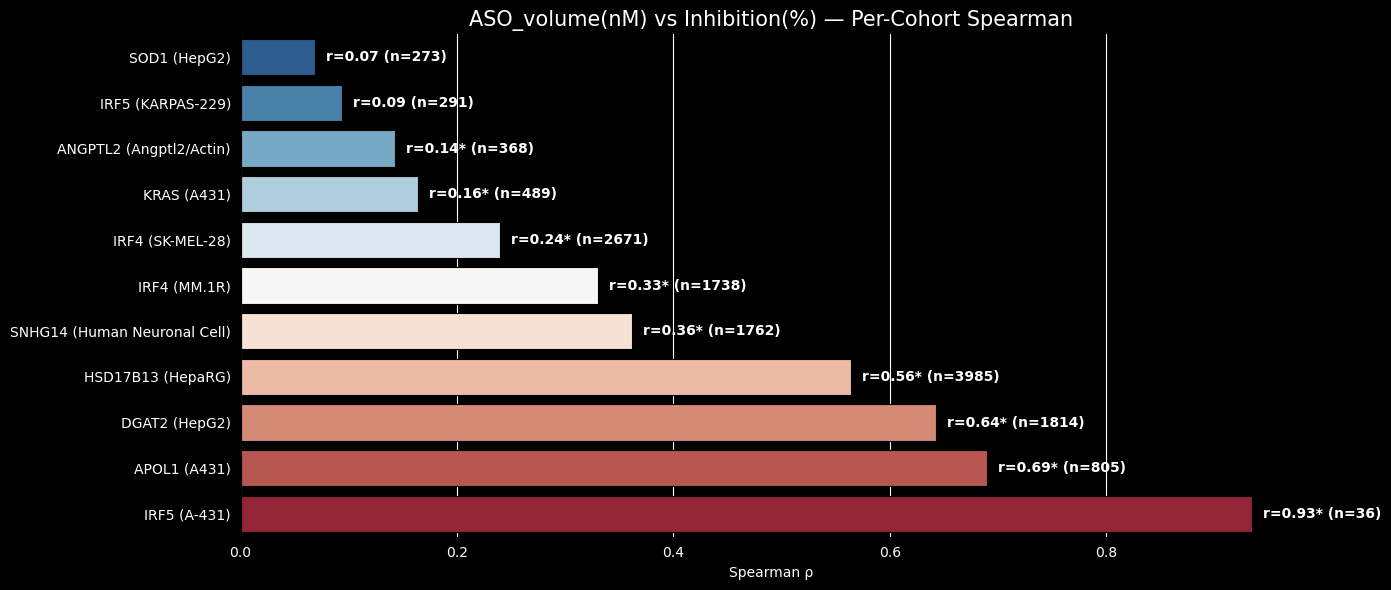

In [5]:
# RBP_interaction_total_right
# RBP_diversity_global_right
# RBP_interaction_stabilizer_right
# RBP_interaction_destabilizer_right
# RBP_interaction_delta_stab_vs_destab_right
# RBP_interaction_ratio_stab_vs_destab_right

FEATURE = VOLUME   # <- you type this
TARGET = INHIBITION     # or log_ec50, etc.

df_corr, df_dropped = analyze_feature_per_cohort(
    merged_df,
    feature=FEATURE,
    target=TARGET,
    min_samples=20,
    verbose=True
)

plot_feature_forest(df_corr, FEATURE, TARGET)
